# Structural aliasing in Chronos-Bolt, Bayesian analysis

**PATCHALIAS / Deliverable 1 §Bayesian Analysis, extended to H2 and H3.**

This notebook runs the complete Bayesian workflow prescribed by the deliverable, over the five
retrained patch/stride geometries of the sweep. It is the *only* notebook in the analysis: the
Chronos side lives in two plain Python modules (`probe_lib.py`, `collect.py`) so that nothing here
has to execute another notebook.

## What is covered by what

| notebook section | deliverable clause | hypothesis | model |
|---|---|---|---|
| 1.2, 3.2, **4.1**, 5.2–5.3 | Local Contrast Analysis, Eq. (8)–(9) | **H1** behavioural | **A**, hierarchical Student-$t_4$ on the paired log contrast $d$ |
| 1.3, 3.2, **4.2** | Absolute Performance Analysis, Eq. (10) | **H1** representational | **B**, Gamma regression, log link, on the frequency-local MDL codelength |
| 1.4, 3.2, **4.3**, 5.4 | *Phase-Invariance Analysis*, Eq. (11) | **H2** | **C**, Model A plus a per-phase-bin offset; the estimand is their spread $\sigma_\phi$ |
| 1.5, 3.2, **4.4**, 5.4 | *Site-Geometry Analysis*, Eq. (12) | **H3** location | **D1**, the token-collapse profile regressed on stride-grid and patch-grid indicators, compared by LOO |
| 1.5, **4.5** | *Site-Geometry Analysis*, Eq. (13) | **H3** movement | **D2**, the measured comb spacing regressed on the predicted $f_s/S$ and $f_s/P$ |

The two *Phase-Invariance* and *Site-Geometry* rows are the extension the lecturers asked for; the
first two rows are the deliverable's original two-part framework.

## The five parts

0. **Setup**, install, repository, Google Drive checkpoints, configuration.
1. **Priors**, specify every prior and check what it implies *before* any data exists.
2. **Observation**, Chronos runs, producing five tidy tables. *The only part that wants a GPU.*
3. **Likelihood**, write the likelihoods out, build the PyMC models, and prove they recover a
   known effect from simulated data.
4. **Posterior inference**, fit A, B, C, D1, D2; credible intervals, ROPEs, LOO comparisons.
5. **Checks**, convergence, posterior predictive, prior sensitivity, and the final verdicts.

**Every part writes a checkpoint.** Re-running the notebook after a Colab disconnect reloads
completed parts instead of recomputing them, so the expensive Part 2 is paid for once. Because the
parts communicate only through checkpoint files, Part 2 can be run on a GPU runtime and Parts
1/3/4/5 on a CPU runtime.

## 0.1, Install

`pymc` + `arviz` are the toolkit used throughout the course labs; `chronos-forecasting` and
`torch` are needed by Part 2 only. The cell installs only what is missing, so re-running it in a
warm runtime costs nothing.

In [1]:
# Colab-friendly install: only fetch what the runtime is missing.
import importlib.util, subprocess, sys

def ensure(pkgs: dict, required: bool) -> list[str]:
    """Install the missing entries of {import_name: pip_name}. Returns what is importable after."""
    missing = [pip for mod, pip in pkgs.items() if importlib.util.find_spec(mod) is None]
    if missing:
        print(("installing" if required else "installing (optional)") + ":", missing)
        try:
            subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])
        except Exception as e:
            if required:
                raise
            # Parts 1/3/4/5 do not need these; the notebook is designed to run without them.
            print(f"  optional install failed ({e}); continuing without it")
    return [mod for mod in pkgs if importlib.util.find_spec(mod) is not None]

# Required everywhere: the Bayesian machinery and the parquet checkpoint format.
ensure({"pymc": "pymc", "arviz": "arviz", "pyarrow": "pyarrow"}, required=True)

# Part 2 only: loading Chronos and running it. Deliberately optional, so that a CPU runtime can
# run Parts 1/3/4/5 against tables a previous GPU run already wrote.
have = ensure({"torch": "torch", "chronos": "chronos-forecasting"}, required=False)
HAVE_TORCH = "torch" in have and "chronos" in have
print({"Part 2 can run in this runtime": HAVE_TORCH})
if not HAVE_TORCH:
    print("  -> switch to a GPU runtime for Part 2, or point Part 0.3 at checkpoints that "
          "already contain its tables.")

{'Part 2 can run in this runtime': True}


## 0.2, Repository

`probe_lib.py` and `collect.py` live in `chronos/bayesian/` of the project repository, next to this
notebook. On Colab we clone the repository; run locally, the cell finds the checkout it is already
inside.

In [2]:
import os, sys
from pathlib import Path

REPO_URL = "https://github.com/FedericoSabbadini/patchAliasing.git"
IN_COLAB = "google.colab" in sys.modules

MARKER = Path("chronos") / "bayesian" / "probe_lib.py"

def find_repo() -> Path:
    """Locate chronos/bayesian: walk up from the CWD, else clone the repository."""
    here = Path.cwd()
    for cand in [here, *here.parents]:
        if (cand / MARKER).exists():
            return cand

    target = Path("/content/patchAliasing") if IN_COLAB else here / "patchAliasing"
    if not (target / MARKER).exists():
        import subprocess
        subprocess.check_call(["git", "clone", "--depth", "1", REPO_URL, str(target)])

    if not (target / MARKER).exists():
        # Fail here, with the actual cause, rather than as a confusing ModuleNotFoundError later.
        raise FileNotFoundError(
            f"{MARKER} is missing from {target}.\n"
            f"The analysis modules have to be on the branch {REPO_URL} clones (its default "
            f"branch). Either push them, or upload probe_lib.py and collect.py by hand:\n"
            f"    from google.colab import files; files.upload()\n"
            f"then place them in {target / 'chronos' / 'bayesian'}.")
    return target

REPO = find_repo()
BAYES_DIR = REPO / "chronos" / "bayesian"
sys.path.insert(0, str(BAYES_DIR))       # so `import probe_lib` / `import collect` resolve
print("repository :", REPO)
print("modules    :", BAYES_DIR)

repository : C:\Users\feder\Desktop\patchAliasing
modules    : C:\Users\feder\Desktop\patchAliasing\chronos\bayesian


## 0.3, Imports, seed, checkpoints

Checkpoints go to Google Drive when it is available, so a disconnected runtime does not throw away
Part 2's Chronos work; otherwise they fall back to the ephemeral `/content` disk.

`SMOKE` shrinks every grid to a few points. Smoke output is written to a **separate** directory and
every part prints a banner, so a fast pipeline check can never be mistaken for a reportable run.

In [3]:
from __future__ import annotations

import json, random, warnings
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import arviz as az
import pymc as pm
from scipy import stats

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid")

# ---- reproducibility: one seed for python, numpy and every PyMC sampler call ----------
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
RNG = np.random.default_rng(SEED)

# ---- run mode -------------------------------------------------------------------------
# SMOKE = True  -> tiny grids and short chains; ~5 minutes end to end. Use it to verify the
#                  pipeline runs, NEVER to report numbers.
# SMOKE = False -> the design written in the deliverable.
SMOKE = False
RESUME = True                 # reload a part from its checkpoint instead of recomputing it

DRAWS, TUNE, CHAINS = (400, 400, 2) if SMOKE else (2000, 2000, 4)
TARGET_ACCEPT = 0.9

# ---- who runs NUTS ---------------------------------------------------------------------
# The hierarchy in Model A carries one effect per background draw, so with the full design it is
# a few hundred parameters over tens of thousands of rows, and PyMC's own sampler takes hours on a
# CPU. The model is unchanged by this setting; only the implementation is.
#   "pymc"     default, CPU only, slowest
#   "nutpie"   Rust, same CPU, typically several times faster
#   "numpyro"  JAX, and the ONLY option that uses a GPU. On a Colab GPU runtime this is the one
#              worth having: PyMC's sampler leaves the GPU idle.
NUTS_BACKEND = "nutpie"

if NUTS_BACKEND != "pymc":
    import importlib.util, subprocess
    _pkg = {"numpyro": "numpyro", "nutpie": "nutpie"}[NUTS_BACKEND]
    if importlib.util.find_spec(_pkg) is None:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", _pkg])
    if NUTS_BACKEND == "numpyro":
        import jax
        print("JAX devices:", jax.devices())        # confirm a GPU is actually visible
print(f"NUTS backend: {NUTS_BACKEND}")

# ---- checkpoints ----------------------------------------------------------------------
def _mount_drive() -> Path | None:
    """Mount Google Drive if we are on Colab and the user allows it."""
    if not IN_COLAB:
        return None
    try:
        from google.colab import drive
        drive.mount("/content/drive")
        return Path("/content/drive/MyDrive")
    except Exception as e:                       # user declined, or not a Drive-enabled runtime
        print("Drive unavailable, falling back to local storage:", e)
        return None

_drive = _mount_drive()
_root = (_drive / "patchaliasing_bayes") if _drive else (Path("/content") if IN_COLAB else REPO / "chronos" / "bayesian" / "_run")
CKPT_DIR = _root / ("smoke" if SMOKE else "full")
DATA_DIR = CKPT_DIR / "data"          # Part 2's tidy tables (and its per-model shards)
FIG_DIR = CKPT_DIR / "figures"
for d in (CKPT_DIR, DATA_DIR, FIG_DIR):
    d.mkdir(parents=True, exist_ok=True)

RUN_MODE = "SMOKE" if SMOKE else "FULL"

def banner(part: str) -> None:
    tag = "  *** SMOKE RUN, NOT FOR REPORTING ***" if SMOKE else ""
    print("=" * 78); print(f"{part}{tag}"); print("=" * 78)

# --------------------------------------------------------------------------------------- #
#  Making a smoke run impossible to mistake for a result
# --------------------------------------------------------------------------------------- #
# A smoke run produces figures and parquet files that LOOK exactly like real ones. The output
# directory differs, but a figure pasted into a document, or a table opened a week later, carries
# no trace of where it came from. Three marks are added so it always does:
#   1. every saved figure gets a diagonal watermark;
#   2. every saved table gets a `run_mode` column;
#   3. file names are prefixed, so a smoke file cannot overwrite or be mistaken for a full one.
if SMOKE:
    # Patch Figure.savefig, not plt.savefig: the cells below overwhelmingly call the method on a
    # figure they hold (fig.savefig(...)), and plt.savefig delegates to the current figure anyway,
    # so patching the method catches both forms.
    from matplotlib.figure import Figure

    _savefig = Figure.savefig

    def _savefig_marked(self, fname, *a, **kw):
        if not getattr(self, "_smoke_marked", False):
            self.text(0.5, 0.5, "SMOKE RUN\nNOT FOR REPORTING", transform=self.transFigure,
                      fontsize=34, color="crimson", alpha=0.22, rotation=30,
                      ha="center", va="center", zorder=1000, fontweight="bold")
            self._smoke_marked = True          # a figure saved twice is stamped once
        return _savefig(self, fname, *a, **kw)

    Figure.savefig = _savefig_marked

def ckpt(name: str) -> Path:
    # a smoke artefact is named as one, so it cannot be confused with a reportable file even
    # after it has been copied out of its directory
    return CKPT_DIR / (f"SMOKE_{name}" if SMOKE else name)

def have(name: str) -> bool:
    return RESUME and ckpt(name).exists()

def save_idata(idata, name: str):
    idata.to_netcdf(str(ckpt(name)));  print(f"  checkpoint -> {ckpt(name).name}");  return idata

def load_idata(name: str):
    print(f"  checkpoint <- {ckpt(name).name}");  return az.from_netcdf(str(ckpt(name)))

def save_df(df: pd.DataFrame, name: str):
    out = df.copy()
    out["run_mode"] = RUN_MODE          # travels with the table wherever it is opened
    out.to_parquet(ckpt(name), index=False);  print(f"  checkpoint -> {ckpt(name).name}");  return df

def load_df(name: str) -> pd.DataFrame:
    """Reload a checkpointed table.

    `run_mode` is dropped on the way in, and a mode mismatch is refused outright: the column exists
    so a parquet opened elsewhere says where it came from, not so it travels into the analysis. It
    also keeps a resumed run identical to a fresh one, which would otherwise carry one extra column.
    """
    df = pd.read_parquet(ckpt(name))
    print(f"  checkpoint <- {ckpt(name).name}")
    if "run_mode" in df.columns:
        found = str(df["run_mode"].iloc[0]) if len(df) else RUN_MODE
        if found != RUN_MODE:
            raise RuntimeError(f"{ckpt(name).name} was written by a {found} run but this is a "
                               f"{RUN_MODE} run. Delete it rather than mixing the two.")
        df = df.drop(columns="run_mode")
    return df

def cached_fit(name: str, build_and_sample):
    """Sample a model, or reload it if this part already ran. The unit of resumption is one model."""
    if have(name):
        return load_idata(name)
    return save_idata(build_and_sample(), name)

print(f"checkpoints : {CKPT_DIR}")
print(f"mode        : {RUN_MODE}   draws={DRAWS} tune={TUNE} chains={CHAINS}")
if SMOKE:
    print("\n" + "!" * 78)
    print("!!  SMOKE RUN. Tiny grids and short chains, for checking that the pipeline runs.")
    print("!!  Every number, figure and table it produces is meaningless and must not be")
    print("!!  reported. Figures are watermarked, tables carry run_mode='SMOKE', and files are")
    print("!!  written to this directory with a SMOKE_ prefix.")
    print("!!  For a reportable run set SMOKE = False in Part 0.3 and re-run from the top.")
    print("!" * 78)

g++ not available, if using conda: `conda install gxx`


NUTS backend: nutpie
checkpoints : C:\Users\feder\Desktop\patchAliasing\chronos\bayesian\_run\full
mode        : FULL   draws=2000 tune=2000 chains=4


## 0.4, The experimental design constants

`probe_lib` is the single source of truth for the design: sampling rate, context length, the five
geometries, and the lock geometry $\mathcal F_{lock}=\{c f_s/S\}\cup\{k f_s/P\}$ of Eq. (7).
Importing it here costs nothing, it pulls in NumPy only, and defers `torch` and the signal
generators until a model is actually constructed, so Parts 1/3/4/5 run in a torch-free runtime.

In [4]:
import probe_lib as pl

print(f"fs = {pl.FS} Hz    context = {pl.CTX} samples    horizon = {pl.PRED}    band = {pl.BAND} Hz")
print(f"tone SNR over background = {pl.TONE_SNR}     generators = {pl.GENERATORS}\n")

rows = []
for (P, S) in pl.MODELS:
    # the control offset is chosen per site (deliverable2.tex, "What enters the inference"): the
    # largest offset not exceeding 0.25*fs/S that keeps BOTH controls clear of BOTH grids.
    offs = {f: pl.control_offset(P, S, f) for f in pl.f_lock(P, S)}
    locks = list(offs)
    clean = [f for f, d in offs.items() if np.isfinite(d)]
    used = [offs[f] for f in clean]
    # a stride lock that is not also a patch null: the only frequency at which a behavioural loss
    # is attributable to the stride branch alone. It exists only where S does not divide P.
    n_so = sum(pl.lock_family(f, P, S) == "stride" for f in locks)
    rows.append(dict(model=pl.model_tag(P, S), P=P, S=S, overlap=(P - S) / P,
                     delta_Hz=("-" if not used else f"{min(used):.2f}"
                               if len(set(np.round(used, 6))) == 1
                               else f"{min(used):.2f}-{max(used):.2f}"),
                     n_lock=len(locks), n_usable=len(clean), stride_only=n_so,
                     stride_locks=", ".join(f"{x:g}" for x in pl.stride_locks(S)[:4]) + " ...",
                     patch_nulls=", ".join(f"{x:g}" for x in pl.patch_nulls(P)[:4]) + " ..."))
design = pd.DataFrame(rows)
display(design)

print("\nn_usable < n_lock only where NO offset below 0.25*fs/S keeps both controls clear of both "
      "grids; such a site is dropped rather than compared against another lock. delta_Hz is a range "
      "where different sites of one geometry needed different offsets.")
print(f"\nstride-only sites in this collection: {design['stride_only'].sum()} "
      f"(tab:patchStride expects 16 over the full nine-run design: 4 at p16-s12, 4 at p24-s16, "
      f"8 at p24-s20).")
gaps = pl.design_gaps()
if gaps:
    print("\n!! the geometries available to this run do not identify everything the deliverable "
          "claims:")
    for g in gaps:
        print("   -", g)
    print("   Fits below are still produced, but an estimand named here must be reported as not "
          "identified rather than as a null result.")
print("\nS = 4 is absent by design: deliverable1.tex excludes it because its stride-lock class has a "
      "single in-band member, so it carries no local H1 contrast.")

fs = 512 Hz    context = 480 samples    horizon = 64    band = (2.0, 250.0) Hz
tone SNR over background = 4.0     generators = ('tsmixup', 'kernelsynth')



,model,P,S,overlap,delta_Hz,n_lock,n_usable,stride_only,stride_locks,patch_nulls
0,p8-s4,8,4,0.500000,32.00,3,3,0,128 ...,"64, 128, 192 ..."
1,p8-s8,8,8,0.000000,16.00,3,3,0,"64, 128, 192 ...","64, 128, 192 ..."
2,p16-s4,16,4,0.750000,26.00-31.00,7,7,0,128 ...,"32, 64, 96, 128 ..."
3,p16-s8,16,8,0.500000,16.00,7,7,0,"64, 128, 192 ...","32, 64, 96, 128 ..."
4,p16-s12,16,12,0.250000,9.67-10.67,11,11,4,"42.6667, 85.3333, 128, 170.667 ...","32, 64, 96, 128 ..."
5,p16-s16,16,16,0.000000,8.00,7,7,0,"32, 64, 96, 128 ...","32, 64, 96, 128 ..."
6,p24-s8,24,8,0.666667,15.30-16.00,11,11,0,"64, 128, 192 ...","21.3333, 42.6667, 64, 85.3333 ..."
7,p24-s12,24,12,0.500000,10.67,11,11,0,"42.6667, 85.3333, 128, 170.667 ...","21.3333, 42.6667, 64, 85.3333 ..."
8,p24-s16,24,16,0.333333,8.00,15,15,4,"32, 64, 96, 128 ...","21.3333, 42.6667, 64, 85.3333 ..."
9,p24-s20,24,20,0.166667,6.40,19,19,8,"25.6, 51.2, 76.8, 102.4 ...","21.3333, 42.6667, 64, 85.3333 ..."



n_usable < n_lock only where NO offset below 0.25*fs/S keeps both controls clear of both grids; such a site is dropped rather than compared against another lock. delta_Hz is a range where different sites of one geometry needed different offsets.

stride-only sites in this collection: 36 (tab:patchStride expects 16 over the full nine-run design: 4 at p16-s12, 4 at p24-s16, 8 at p24-s20).

!! the geometries available to this run do not identify everything the deliverable claims:
   - not yet trained: p8-s5, p16-s15, p24-s15, p32-s15, p32-s28
   Fits below are still produced, but an estimand named here must be reported as not identified rather than as a null result.

S = 4 is absent by design: deliverable1.tex excludes it because its stride-lock class has a single in-band member, so it carries no local H1 contrast.


---
# Part 1, Priors

The deliverable's Bayesian section names a prior for every parameter. This part does two things
with them, **before any observation exists**:

1. writes them down in one table, so the reported analysis and the document cannot drift apart;
2. checks what they *imply*. A prior is not weakly informative because it is labelled weakly
   informative, it is weakly informative if the data it predicts are plausible and if it does not
   quietly assert the conclusion. We therefore push each prior through its own likelihood and look
   at the resulting distribution of the quantities we care about: the recovery ratio $e^{\bar\beta}$,
   the codelength ratio $e^{\theta_{lock}}$, the shape of a collapse comb.

Nothing here needs Chronos: the *design* (which geometries, which lock sites, which phases) is
fixed in advance by `probe_lib`, and only the responses are unknown. That is precisely what makes a
genuine prior predictive check possible.

In [5]:
banner("PART 1, PRIORS")

# Prior scales are preregistered here, including the sensitivity ladder used in Part 5.
PRIOR_SCALE = 0.5                       # the deliverable's primary choice
PRIOR_LADDER = [0.25, 0.5, 1.0]         # sceptical / primary / wide, for the sensitivity refits
NU = 4                                  # Student-t degrees of freedom, as written in the .tex

# Decision thresholds, preregistered so they cannot be chosen after seeing the posterior.
ATTENUATION_20 = np.log(0.8)            # "at least 20% attenuation"  ->  beta < log 0.8
ROPE_LOG = np.log(1.1)                  # practical equivalence: a +/-10% effect is no effect
ROPE_SLOPE = 0.1                        # H3a / H3b movement: |kappa_F - 1| < 0.1

PRIOR_SPEC = pd.DataFrame([
    # model, parameter, prior, role, where it is written in the deliverable
    ("A/C", "beta_bar",      f"StudentT(nu=4, 0, {PRIOR_SCALE})",  "population phase-lock effect on log-recovery", "Eq. (9)"),
    ("A",   "delta_O",       f"StudentT(nu=4, 0, {PRIOR_SCALE})",  "slope in the centred overlap Otilde; M1", "Eq. (9)"),
    ("A",   "delta_P",       f"StudentT(nu=4, 0, {PRIOR_SCALE})",  "slope in the centred log patch size", "Eq. (9)"),
    ("A/C", "tau",           f"HalfStudentT(nu=4, {PRIOR_SCALE})", "spread of configuration effects", "Eq. (9)"),
    ("A/C", "sigma_harm",    f"HalfStudentT(nu=4, {PRIOR_SCALE})", "spread across lock harmonics", "Eq. (9)"),
    ("A/C", "sigma_bg",      f"HalfStudentT(nu=4, {PRIOR_SCALE})", "spread across background realisations", "Eq. (9)"),
    ("A/C", "sigma",         f"HalfStudentT(nu=4, {PRIOR_SCALE})", "residual scale of the contrast", "Eq. (9)"),
    ("C",   "sigma_phase",   "HalfNormal(0.25)",                   "spread of the per-phase offsets (8 phase bins)", "Eq. (11)"),
    ("B",   "alpha_0",       "Normal(log mean(y), 1)",             "baseline log codelength", "Eq. (10)"),
    ("B",   "theta_lock",    "Normal(0, 0.5)",                     "log codelength expansion at a lock", "Eq. (10)"),
    ("B",   "k (shape)",     "Gamma(2, 0.1)",                      "Gamma dispersion", "Eq. (10)"),
    ("D1",  "alpha_g",       "Normal(0, 1)",                       "off-grid level of log z_g", "Eq. (12)"),
    ("D1",  "theta_S",       "Normal(0, 1)",                       "dip on the stride grid; H3 predicts < 0", "Eq. (12)"),
    ("D1",  "theta_P",       "Normal(0, 1)",                       "dip on the patch grid; H3 predicts < 0", "Eq. (12)"),
    ("D1",  "sigma",         "HalfNormal(1)",                      "residual scale", "Eq. (12)"),
    ("D2",  "kappa_S",       "Normal(0, 1)",                       "measured / stride-predicted spacing; H3a predicts 1", "Eq. (13)"),
    ("D2",  "kappa_P",       "Normal(0, 1)",                       "measured / patch-predicted spacing; H3b predicts 1", "Eq. (13)"),
    ("D2",  "sigma_extra",   "HalfNormal(5) Hz",                   "scatter beyond the sweep resolution", "Eq. (13)"),
], columns=["model", "parameter", "prior", "role", "deliverable"])
display(PRIOR_SPEC)

PART 1, PRIORS


,model,parameter,prior,role,deliverable
0,A/C,beta_bar,"StudentT(nu=4, 0, 0.5)",population phase-lock effect on log-recovery,Eq. (9)
1,A,delta_O,"StudentT(nu=4, 0, 0.5)",slope in the centred overlap Otilde; M1,Eq. (9)
2,A,delta_P,"StudentT(nu=4, 0, 0.5)",slope in the centred log patch size,Eq. (9)
3,A/C,tau,"HalfStudentT(nu=4, 0.5)",spread of configuration effects,Eq. (9)
4,A/C,sigma_harm,"HalfStudentT(nu=4, 0.5)",spread across lock harmonics,Eq. (9)
5,A/C,sigma_bg,"HalfStudentT(nu=4, 0.5)",spread across background realisations,Eq. (9)
6,A/C,sigma,"HalfStudentT(nu=4, 0.5)",residual scale of the contrast,Eq. (9)
7,C,sigma_phase,HalfNormal(0.25),spread of the per-phase offsets (8 phase bins),Eq. (11)
8,B,alpha_0,"Normal(log mean(y), 1)",baseline log codelength,Eq. (10)
9,B,theta_lock,"Normal(0, 0.5)",log codelength expansion at a lock,Eq. (10)


## 1.1, The design skeleton

Which geometries, lock sites, phases, backgrounds and generators the experiment will visit is
fixed by the design, not by the model. Building that skeleton now lets Part 1 simulate responses
from the prior on exactly the rows Part 2 will later fill in, a real prior predictive check on the
real design, not on a stylised one.

In [6]:
def design_skeleton(n_phase=10, n_bg=6, generators=pl.GENERATORS) -> pd.DataFrame:
    """One row per (geometry, lock site, background, phase), the rows Part 2 will populate.

    Deliberately mirrors collect.collect_contrasts: same lock sites, same control-cleanliness
    filter, same S_f phase sampling. Only the response is missing.
    """
    rows = []
    for (P, S) in pl.MODELS:
        offs = {f: pl.control_offset(P, S, f) for f in pl.f_lock(P, S)}
        for fk in [f for f, d in offs.items() if np.isfinite(d)]:
            for gen in generators:
                for bg_id in range(n_bg):
                    for j, ph in enumerate(pl.phases_Sf(fk, n_phase)):
                        rows.append(dict(model=pl.model_tag(P, S), P=P, S=S,
                                         overlap=(P - S) / P, f_lock=fk,
                                         family=pl.lock_family(fk, P, S),
                                         generator=gen, bg_id=bg_id,
                                         phase_idx=j, phase=float(ph)))
    return pd.DataFrame(rows)

SKELETON = design_skeleton(n_phase=2 if SMOKE else 10, n_bg=1 if SMOKE else 6,
                           generators=("tsmixup",) if SMOKE else pl.GENERATORS)
print(f"planned contrast observations: {len(SKELETON)}")
display(SKELETON.groupby("model").agg(rows=("f_lock", "size"), locks=("f_lock", "nunique"),
                                      phases=("phase_idx", "nunique")))

planned contrast observations: 23148


,rows,locks,phases
model,,,
p16-s12,1164,11,10
p16-s16,684,7,10
p16-s4,684,7,10
p16-s8,684,7,10
p24-s12,1164,11,10
p24-s16,1644,15,10
p24-s20,2124,19,10
p24-s24,1164,11,10
p24-s8,1164,11,10


## 1.2, Prior predictive for Models A and C (H1 behavioural, H2)

The contrast $d$ lives on a log-ratio scale, so $\bar\beta$ is read as $e^{\bar\beta}$: the
multiplicative change in forecast amplitude recovery at a lock relative to its controls. The
question a prior predictive answers is whether $\text{Student-}t_4(0, 0.5)$ describes *ignorance*
about that ratio or a belief about it.

Three things are checked:

* the prior is symmetric, it gives attenuation and amplification the same mass, so finding
  attenuation cannot be an artefact of the prior;
* it reaches far enough, a scale of $0.5$ puts $e^{\pm 0.5}\approx 1.65$ at one scale unit and the
  heavy $t_4$ tails admit far larger effects, so a real strong effect will not be shrunk away;
* the simulated contrasts $d$ are on the same order as contrasts that could physically occur
  (recovery ratios are bounded below by 0 and rarely exceed a few).

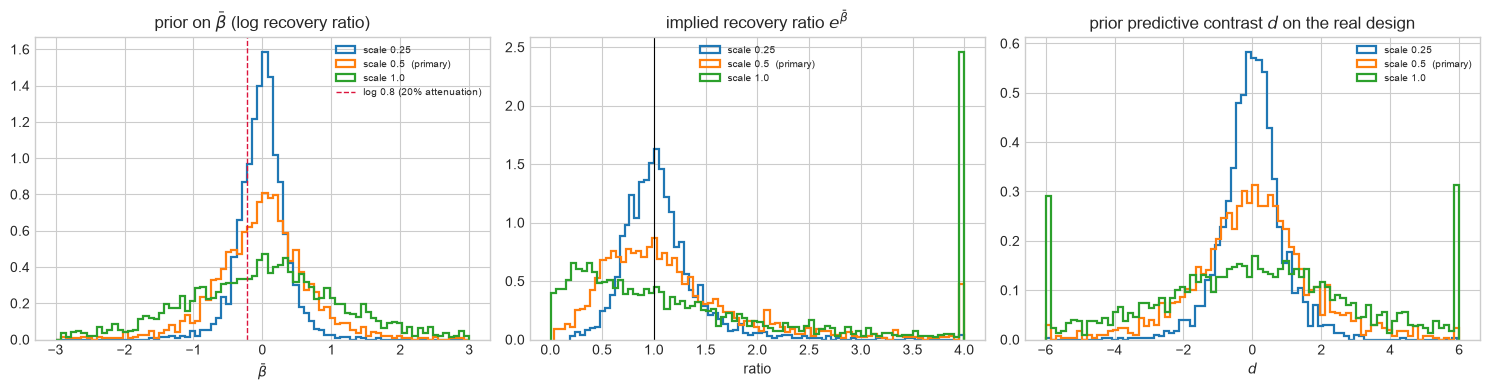

under the primary prior (scale 0.5):
  P(beta_bar < 0)                 = 0.500   <- 0.5 means symmetric: the prior does not favour the hypothesis
  P(>=20% attenuation) a priori   = 0.336
  P(>=50% attenuation) a priori   = 0.122   <- reachable, so a real strong effect will not be shrunk away
  central 95% of the ratio        = [0.25, 4.03]


In [7]:
def simulate_contrast_prior(skeleton: pd.DataFrame, scale: float, n_draw: int = 2000,
                            rng=None) -> dict:
    """Draw parameters from the Model A prior and push them through the likelihood.

    Returns both the population-level effect draws and simulated contrasts on the real design, so
    the prior can be judged on the data it predicts rather than on its own parameters.
    """
    rng = rng or np.random.default_rng(SEED)
    cfg_codes, cfg_index = pd.factorize(skeleton["model"])
    harm_codes, _ = pd.factorize(skeleton["f_lock"].round(3))
    bg_codes, _ = pd.factorize(skeleton["generator"] + "#" + skeleton["bg_id"].astype(str))
    O = skeleton.groupby("model")["overlap"].first().reindex(cfg_index).to_numpy()
    O_t = (O - O.mean()) / 0.5                       # one unit = 0.5 of patch overlap

    # priors, exactly as tabulated above
    beta_bar = stats.t.rvs(NU, scale=scale, size=n_draw, random_state=rng.integers(1 << 31))
    delta_O = stats.t.rvs(NU, scale=scale, size=n_draw, random_state=rng.integers(1 << 31))
    half = lambda: np.abs(stats.t.rvs(NU, scale=scale, size=n_draw,
                                      random_state=rng.integers(1 << 31)))
    tau, sig_h, sig_b, sigma = half(), half(), half(), half()

    # one simulated dataset per draw would be huge; simulate a random design row per draw instead,
    # which gives the marginal prior predictive of a single observation
    i = rng.integers(0, len(skeleton), n_draw)
    beta_c = beta_bar + delta_O * O_t[cfg_codes[i]] + tau * rng.normal(size=n_draw)
    mu = beta_c + sig_h * rng.normal(size=n_draw) + sig_b * rng.normal(size=n_draw)
    d = mu + sigma * stats.t.rvs(NU, size=n_draw, random_state=rng.integers(1 << 31))
    return dict(beta_bar=beta_bar, delta_O=delta_O, d=d, ratio=np.exp(beta_bar))


fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for scale in PRIOR_LADDER:
    sim = simulate_contrast_prior(SKELETON, scale)
    lbl = f"scale {scale}" + ("  (primary)" if scale == PRIOR_SCALE else "")
    axes[0].hist(sim["beta_bar"], bins=80, range=(-3, 3), histtype="step", lw=1.6, label=lbl, density=True)
    axes[1].hist(np.clip(sim["ratio"], 0, 4), bins=80, histtype="step", lw=1.6, label=lbl, density=True)
    axes[2].hist(np.clip(sim["d"], -6, 6), bins=80, histtype="step", lw=1.6, label=lbl, density=True)

axes[0].axvline(ATTENUATION_20, color="crimson", ls="--", lw=1, label="log 0.8 (20% attenuation)")
axes[0].set_title(r"prior on $\bar\beta$ (log recovery ratio)"); axes[0].set_xlabel(r"$\bar\beta$")
axes[1].axvline(1.0, color="k", lw=0.8)
axes[1].set_title(r"implied recovery ratio $e^{\bar\beta}$"); axes[1].set_xlabel("ratio")
axes[2].set_title("prior predictive contrast $d$ on the real design"); axes[2].set_xlabel("$d$")
for a in axes: a.legend(fontsize=7)
fig.tight_layout(); fig.savefig(FIG_DIR / "P1_prior_predictive_contrast.png", dpi=140,
                                bbox_inches="tight"); plt.show()

sim = simulate_contrast_prior(SKELETON, PRIOR_SCALE, n_draw=20000)
print(f"under the primary prior (scale {PRIOR_SCALE}):")
print(f"  P(beta_bar < 0)                 = {np.mean(sim['beta_bar'] < 0):.3f}   <- 0.5 means symmetric: "
      f"the prior does not favour the hypothesis")
print(f"  P(>=20% attenuation) a priori   = {np.mean(sim['beta_bar'] < ATTENUATION_20):.3f}")
print(f"  P(>=50% attenuation) a priori   = {np.mean(sim['beta_bar'] < np.log(0.5)):.3f}   <- reachable, "
      f"so a real strong effect will not be shrunk away")
print(f"  central 95% of the ratio        = [{np.exp(np.quantile(sim['beta_bar'], .025)):.2f}, "
      f"{np.exp(np.quantile(sim['beta_bar'], .975)):.2f}]")

### The H2 phase term

Model C cuts the phase circle into eight equal slices and gives each its own offset. The estimand
$\sigma_\phi$ is the spread of those offsets: how much the lock deficit moves as the signal slides
through its cycle. Its prior, $\text{Half-}\mathcal N(0,0.25)$, puts mass on both sides of the
equivalence boundary $\log 1.1$, so the H2 verdict is decided by the data rather than by the prior.

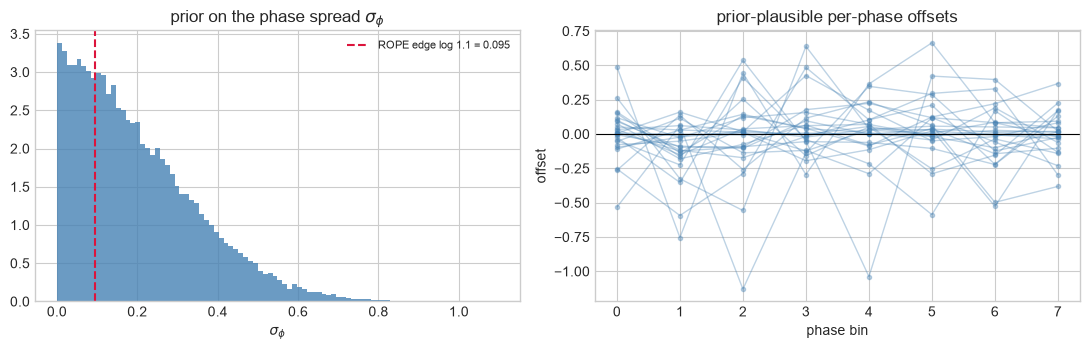

P(sigma_phase < ROPE) a priori = 0.299   <- mass on both sides, so the H2 verdict comes from the data, not this prior


In [8]:
sigma_phase_prior = np.abs(RNG.normal(0, 0.25, 40000))     # Half-Normal(0.25)

fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
ax[0].hist(sigma_phase_prior, bins=90, density=True, color="steelblue", alpha=.8)
ax[0].axvline(ROPE_LOG, color="crimson", ls="--", label=f"ROPE edge log 1.1 = {ROPE_LOG:.3f}")
ax[0].set_title(r"prior on the phase spread $\sigma_\phi$"); ax[0].legend(fontsize=8)
ax[0].set_xlabel(r"$\sigma_\phi$")

# what a prior-plausible set of per-phase offsets looks like
for _ in range(25):
    ax[1].plot(np.arange(N_PHASE_BINS := 8),
               RNG.choice(sigma_phase_prior) * RNG.normal(size=8),
               marker="o", ms=3, alpha=.35, lw=1, color="steelblue")
ax[1].axhline(0, color="k", lw=.8)
ax[1].set_xlabel("phase bin"); ax[1].set_ylabel("offset")
ax[1].set_title("prior-plausible per-phase offsets")
fig.tight_layout(); fig.savefig(FIG_DIR / "P1_prior_predictive_phase.png", dpi=140,
                                bbox_inches="tight"); plt.show()

print(f"P(sigma_phase < ROPE) a priori = {np.mean(sigma_phase_prior < ROPE_LOG):.3f}   "
      f"<- mass on both sides, so the H2 verdict comes from the data, not this prior")

## 1.3, Prior predictive for Model B (H1 representational)

The response is a prequential codelength in bits: strictly positive, right-skewed, and with a
variance that grows with its mean. That is what the Gamma likelihood with a log link is for, and it
is why $\theta_{lock}$ is read multiplicatively, $e^{\theta_{lock}}$ is the factor by which
describing the labels costs more at a locked frequency.

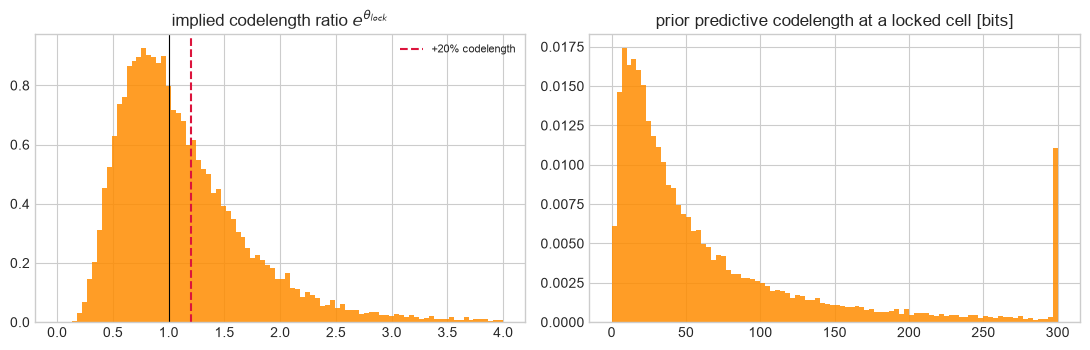

P(theta_lock > 0) a priori          = 0.494   <- symmetric
P(codelength expands by >=20%)      = 0.357
prior predictive codelength median  = 37.3 bits (95% CI 3.8-361.2) -- positive and right-skewed, as a codelength must be


In [9]:
n = 20000
alpha0_p = RNG.normal(np.log(40.0), 1.0, n)      # 40 bits is a plausible baseline for a 80-example cell
theta_p = RNG.normal(0.0, 0.5, n)                # Eq. (10) prior
k_p = RNG.gamma(2.0, 1 / 0.1, n)                 # Gamma(2, rate=0.1): mean 20, wide
mu_locked = np.exp(alpha0_p + theta_p)
y_locked = RNG.gamma(k_p, mu_locked / k_p)       # PyMC's (alpha=k, beta=k/mu) parameterisation

fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
ax[0].hist(np.exp(theta_p), bins=90, range=(0, 4), density=True, color="darkorange", alpha=.85)
ax[0].axvline(1, color="k", lw=.8); ax[0].axvline(1.2, color="crimson", ls="--", label="+20% codelength")
ax[0].set_title(r"implied codelength ratio $e^{\theta_{lock}}$"); ax[0].legend(fontsize=8)
ax[1].hist(np.clip(y_locked, 0, 300), bins=90, density=True, color="darkorange", alpha=.85)
ax[1].set_title("prior predictive codelength at a locked cell [bits]")
fig.tight_layout(); fig.savefig(FIG_DIR / "P1_prior_predictive_codelength.png", dpi=140,
                                bbox_inches="tight"); plt.show()

print(f"P(theta_lock > 0) a priori          = {np.mean(theta_p > 0):.3f}   <- symmetric")
print(f"P(codelength expands by >=20%)      = {np.mean(theta_p > np.log(1.2)):.3f}")
print(f"prior predictive codelength median  = {np.median(y_locked):.1f} bits "
      f"(95% CI {np.quantile(y_locked, .025):.1f}-{np.quantile(y_locked, .975):.1f}) "
      f"-- positive and right-skewed, as a codelength must be")

## 1.4, Prior predictive for Models D1 and D2 (H3)

D1 asks whether the token dispersion is lower on a predicted grid than off it: $\theta_S$ is that
difference, on a log scale, and H3 predicts $\theta_S<0$. Its $\mathcal N(0,1)$ prior is symmetric,
so a dip is not assumed.

D2 asks whether the measured comb spacing follows the predicted one. It is a plain regression of
measured spacing on $f_s/S$ and $f_s/P$, and **H3 predicts a slope of exactly 1 on $f_s/S$ and 0 on
$f_s/P$**. The prior on both slopes is centred on $0$, *no* relationship, so the hypothesis has to
be earned from the data.

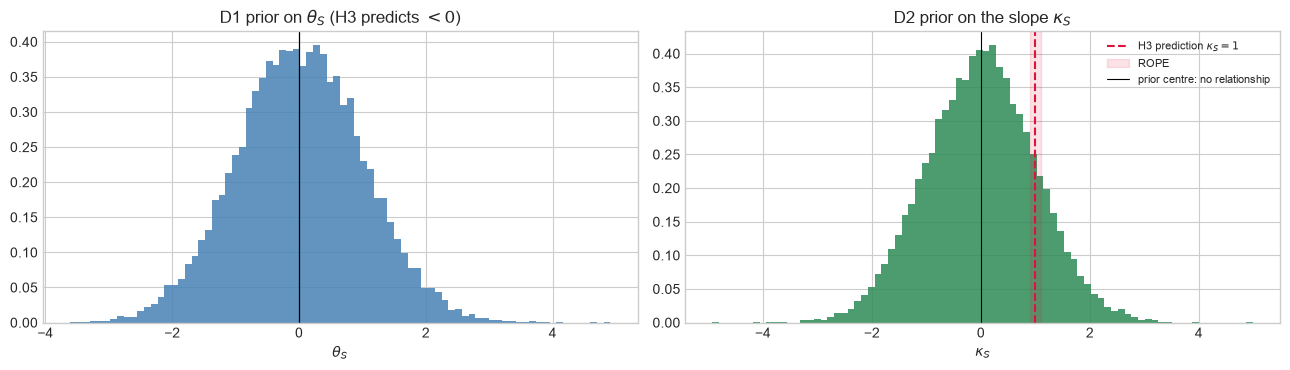

P(kappa_S in ROPE around 1) a priori = 0.048   <- small, so landing there is evidence, not a prior artefact


In [10]:
fig, ax = plt.subplots(1, 2, figsize=(13, 3.8))

theta_S = RNG.normal(0, 1, 20000)
ax[0].hist(theta_S, bins=80, density=True, color="steelblue", alpha=.85)
ax[0].axvline(0, color="k", lw=.9)
ax[0].set_title(r"D1 prior on $\theta_S$ (H3 predicts $<0$)"); ax[0].set_xlabel(r"$\theta_S$")

kappa_S = RNG.normal(0, 1, 20000)
ax[1].hist(kappa_S, bins=80, density=True, color="seagreen", alpha=.85)
ax[1].axvline(1.0, color="crimson", ls="--", lw=1.5, label=r"H3 prediction $\kappa_S=1$")
ax[1].axvspan(1 - ROPE_SLOPE, 1 + ROPE_SLOPE, color="crimson", alpha=.12, label="ROPE")
ax[1].axvline(0.0, color="k", lw=.8, label="prior centre: no relationship")
ax[1].set_title(r"D2 prior on the slope $\kappa_S$"); ax[1].legend(fontsize=8)
ax[1].set_xlabel(r"$\kappa_S$")
fig.tight_layout(); fig.savefig(FIG_DIR / "P1_prior_predictive_H3.png", dpi=140,
                                bbox_inches="tight"); plt.show()

print(f"P(kappa_S in ROPE around 1) a priori = {np.mean(np.abs(kappa_S - 1) < ROPE_SLOPE):.3f}   "
      f"<- small, so landing there is evidence, not a prior artefact")

## 1.5, Checkpoint

The prior specification and its predictive summaries are stored so the reported analysis can be
traced back to priors that were fixed before the data existed.

In [11]:
prior_summary = dict(
    prior_scale=PRIOR_SCALE, prior_ladder=PRIOR_LADDER, nu=NU,
    attenuation_20=float(ATTENUATION_20), rope_log=float(ROPE_LOG), rope_slope=ROPE_SLOPE,
    p_attenuation20_prior=float(np.mean(sim["beta_bar"] < ATTENUATION_20)),
    p_sigma_phase_in_rope_prior=float(np.mean(sigma_phase_prior < ROPE_LOG)),
    p_kappaS_in_rope_prior=float(np.mean(np.abs(kappa_S - 1) < ROPE_SLOPE)),
    planned_contrast_rows=int(len(SKELETON)), smoke=SMOKE, seed=SEED,
)
(ckpt("01_prior_spec.json")).write_text(json.dumps(prior_summary, indent=2))
save_df(PRIOR_SPEC, "01_prior_spec.parquet")
print(json.dumps(prior_summary, indent=2))

  checkpoint -> 01_prior_spec.parquet
{
  "prior_scale": 0.5,
  "prior_ladder": [
    0.25,
    0.5,
    1.0
  ],
  "nu": 4,
  "attenuation_20": -0.2231435513142097,
  "rope_log": 0.09531017980432493,
  "rope_slope": 0.1,
  "p_attenuation20_prior": 0.33585,
  "p_sigma_phase_in_rope_prior": 0.2987,
  "p_kappaS_in_rope_prior": 0.0479,
  "planned_contrast_rows": 23148,
  "smoke": false,
  "seed": 42
}


---
# Part 2, Observation: Chronos produces the data

This is the only part that loads a model, and the only part that wants a GPU. It runs
`collect.py`, which visits the five geometries and writes five tidy tables. Everything after this
point treats those tables as plain data.

**What is measured, and why each measurement exists**

| table | measurement | why |
|---|---|---|
| `contrasts` | forecast amplitude recovery $R$ at each lock $f_k$ and at both controls $f_k\pm 0.25 f_s/S$, sharing background and phase | the *behavioural* endpoint of Eq. (8); the phase index is kept so H2 is testable |
| `mdl_cells` | prequential codelength $L(D)$ of a probe separating $f_c-1$ Hz from $f_c+1$ Hz, per probe stage | the *representational* endpoint of Eq. (10) |
| `mdl_bandtasks` | the seven hierarchical band tasks, with shuffled-label and random-init controls | descriptive cross-check of overall decodability |
| `collapse` | across-patch token dispersion $z_g(f)$ on the union grid, in three signal modes | the location endpoint of Eq. (12) |
| `sites` | detected collapse sites, their fundamental $f_1$ and spacing $\hat\Delta$ | the movement endpoint of Eq. (13) |

**Signals.** Following the deliverable's Data section, the tone rides on a unit-variance
**TSMixup** or **KernelSynth** background at SNR 4, the two synthetic corpora the project
generates. The collapse sweep additionally records the **pure sinusoid** mode, because only there
is the degeneracy exact ($z=0$ when consecutive patches coincide); the background modes show the
same comb as a deep dip and are the realistic-signal cross-check.

**Resumption.** `collect.py` shards per geometry under `data/raw/`. A geometry whose shards exist
is skipped *and its model is never loaded*, so an interrupted run costs only the geometry it died
on.

In [12]:
banner("PART 2, OBSERVATION (Chronos)")

import collect

CFG = collect.Config.smoke_cfg() if SMOKE else collect.Config()
# Colab's T4 handles 64 contexts per forward pass comfortably; drop it if you hit OOM.
CFG.batch_size = 32 if SMOKE else 64

print("design:", {k: v for k, v in vars(CFG).items() if k != "generators"})
print("generators:", CFG.generators)
print("\nexpected forward passes (order of magnitude):")
def _n_usable(P, S):
    return int(sum(np.isfinite(pl.control_offset(P, S, f)) for f in pl.f_lock(P, S)))

n_ctr = sum(3 * _n_usable(P, S) * CFG.n_phase_contrast * CFG.n_bg * len(CFG.generators)
            for P, S in pl.MODELS)
n_mdl = sum(2 * CFG.mdl_n_per_class * 3 * _n_usable(P, S) for P, S in pl.MODELS)
n_col = len(pl.union_grid(pl.MODELS, CFG.collapse_step)) * CFG.collapse_reps * len(CFG.collapse_modes) * len(pl.MODELS)
print(f"  contrasts {n_ctr:>7,d}   mdl_cells {n_mdl:>7,d}   collapse {n_col:>7,d}   "
      f"total {n_ctr + n_mdl + n_col:>8,d}")

PART 2, OBSERVATION (Chronos)
design: {'smoke': False, 'batch_size': 64, 'device': None, 'n_phase_contrast': 10, 'n_bg': 100, 'mdl_delta_f': 1.0, 'mdl_n_per_class': 40, 'mdl_n_phase': 10, 'mdl_n_bg': 10, 'band_tasks': True, 'bt_step': 2.0, 'bt_n_phase': 4, 'bt_random_init': True, 'collapse_step': 1.0, 'collapse_reps': 3, 'collapse_modes': ('pure', 'tsmixup', 'kernelsynth'), 'seed': 42}
generators: ('tsmixup', 'kernelsynth')

expected forward passes (order of magnitude):
  contrasts 1,290,000   mdl_cells  51,600   collapse  40,545   total 1,382,145


In [13]:
# Run the collection. Already-complete geometries are skipped without loading their model, so this
# cell is safe to re-run after a disconnect.
if HAVE_TORCH:
    DATA = collect.collect_all(DATA_DIR, models=pl.MODELS, cfg=CFG)
else:
    print("torch is not available in this runtime: loading the tables written by a previous "
          "GPU run instead (this is the intended CPU-runtime path).")
    DATA = {name: pd.read_parquet(DATA_DIR / f"02_{name}.parquet")
            for name in collect.TABLES if (DATA_DIR / f"02_{name}.parquet").exists()}
    collect.check_design(DATA)

contrasts = DATA["contrasts"]
mdl_cells = DATA["mdl_cells"]
collapse = DATA["collapse"]
sites = DATA["sites"]
bandtasks = DATA.get("mdl_bandtasks")
print("\nrows:", {k: len(v) for k, v in DATA.items()})

collecting into C:\Users\feder\Desktop\patchAliasing\chronos\bayesian\_run\full\data  |  FULL design  |  17 geometries


  archived 200 signals -> C:\Users\feder\Desktop\patchAliasing\chronos\bayesian\_run\full\data\signals
  p8-s4: all shards present, skipping (model not loaded)
  p8-s8: all shards present, skipping (model not loaded)
  p16-s4: all shards present, skipping (model not loaded)
  p16-s8: all shards present, skipping (model not loaded)
  p16-s12: all shards present, skipping (model not loaded)
  p16-s16: all shards present, skipping (model not loaded)
  p24-s8: all shards present, skipping (model not loaded)
  p24-s12: all shards present, skipping (model not loaded)
  p24-s16: all shards present, skipping (model not loaded)
  p24-s20: all shards present, skipping (model not loaded)
  p24-s24: all shards present, skipping (model not loaded)
  p32-s8: all shards present, skipping (model not loaded)
  p32-s12: all shards present, skipping (model not loaded)
  p32-s16: all shards present, skipping (model not loaded)
  p32-s20: all shards present, skipping (model not loaded)
  p32-s24: all shard


  design check
    contrasts p16-s12   rows=19400 live= 8601 locks= 11 phases= 10 generators=2
    contrasts p16-s16   rows=11400 live= 4000 locks=  7 phases= 10 generators=2
    contrasts p16-s4    rows=11400 live= 6744 locks=  7 phases= 10 generators=2
    contrasts p16-s8    rows=11400 live= 4000 locks=  7 phases= 10 generators=2
    contrasts p24-s12   rows=19400 live= 7733 locks= 11 phases= 10 generators=2
    contrasts p24-s16   rows=27400 live= 8000 locks= 15 phases= 10 generators=2
    contrasts p24-s20   rows=35400 live= 8600 locks= 19 phases= 10 generators=2
    contrasts p24-s24   rows=19400 live= 7689 locks= 11 phases= 10 generators=2
    contrasts p24-s8    rows=19400 live=11342 locks= 11 phases= 10 generators=2
    contrasts p32-s12   rows=35400 live=14495 locks= 19 phases= 10 generators=2
    contrasts p32-s16   rows=27400 live=12000 locks= 15 phases= 10 generators=2
    contrasts p32-s20   rows=43400 live=10598 locks= 23 phases= 10 generators=2
    contrasts p32-s24   

## 2.1, The generated signals

Every number in this analysis traces back to a signal that TSMixup or KernelSynth produced. It is
worth making that concrete, because the generators are easy to lose sight of: they never appear in
a model equation, yet they determine what Chronos was actually shown.

A tone alone would test the geometry in a vacuum. Riding it on a generated background asks the
question the deliverable actually poses, does the phase-lock still cost the model something when
the signal looks like the corpora Chronos was trained on? The two generators enter the models as a
**grouping factor**: Models A and C give each background realisation its own offset, with scale
`sigma_bg`. So the generators do not merely produce the inputs, they are a term in the posterior,
and if TSMixup and KernelSynth disagreed, `sigma_bg` would be large and visible rather than silently
averaged into the residual.

The 200 draws are archived to `data/signals/` by the collection step, so the exact inputs behind
every posterior can be reloaded, KernelSynth in particular is a random draw from a
Gaussian-process prior, reproducible only given its seed. Each is stored at its full length; the
shorter version used by the MDL cells and the collapse sweep is its leading samples, so one draw is
one signal everywhere in the analysis.

,generator,n,draws,mean_std
0,kernelsynth,544,100,1.0
1,tsmixup,544,100,1.0


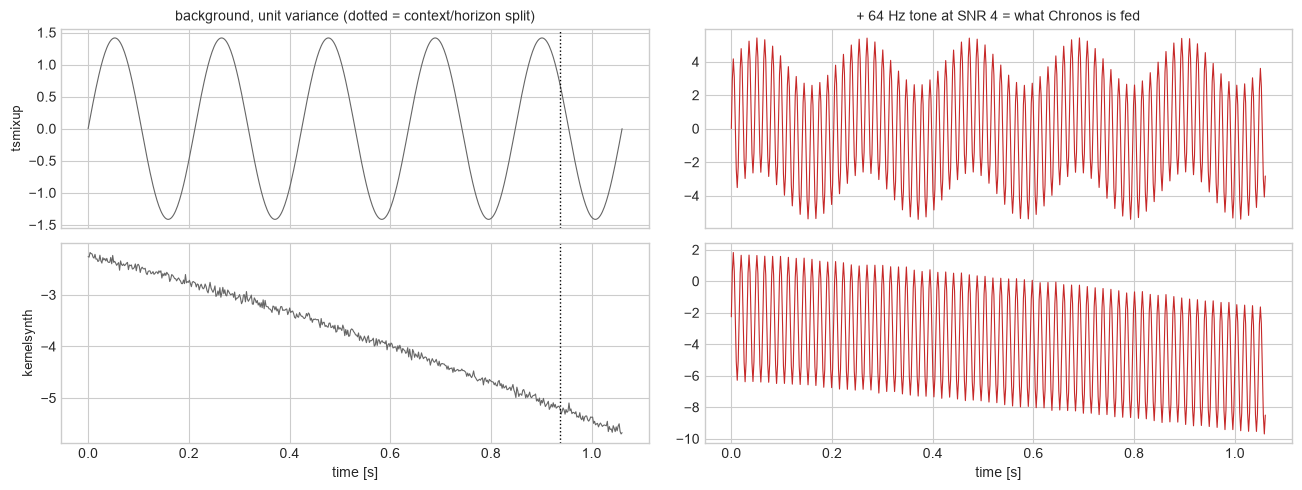


contrast observations by generator:


model,p16-s12,p16-s16,p16-s4,p16-s8,p24-s12,p24-s16,p24-s20,p24-s24,p24-s8,p32-s12,p32-s16,p32-s20,p32-s24,p32-s32,p32-s8,p8-s4,p8-s8
generator,,,,,,,,,,,,,,,,,
kernelsynth,9700,5700,5700,5700,9700,13700,17700,9700,9700,17700,13700,21700,21700,13700,13700,1700,1700
tsmixup,9700,5700,5700,5700,9700,13700,17700,9700,9700,17700,13700,21700,21700,13700,13700,1700,1700


In [14]:
sig_dir = DATA_DIR / "signals"
if (sig_dir / "signals_index.parquet").exists():
    sig_index = pd.read_parquet(sig_dir / "signals_index.parquet")
    display(sig_index.groupby(["generator", "n"]).agg(draws=("file", "size"),
                                                      mean_std=("std", "mean")).reset_index())

    # Each draw is stored at its full length; the shorter version the MDL cells and the collapse
    # sweep use is its leading CTX samples. The injected tone is added here rather than archived,
    # since it is a deterministic function of (frequency, phase).
    fig, axes = plt.subplots(2, 2, figsize=(13, 5), sharex=True)
    for r, gen in enumerate([g for g in pl.GENERATORS if (sig_index.generator == g).any()][:2]):
        bg = np.load(sig_dir / f"background_{gen}_bg0.npy")
        t = np.arange(len(bg)) / pl.FS
        axes[r][0].plot(t, bg, lw=.8, color="0.4")
        axes[r][0].axvline(pl.CTX / pl.FS, color="k", ls=":", lw=1)
        axes[r][0].set_ylabel(gen, fontsize=9)
        if r == 0:
            axes[r][0].set_title("background, unit variance (dotted = context/horizon split)",
                                 fontsize=10)
        ctx = pl.build_context(bg, 64.0, 0.0, len(bg))     # a lock frequency, for illustration
        axes[r][1].plot(t, ctx, lw=.8, color="#c62828")
        if r == 0:
            axes[r][1].set_title("+ 64 Hz tone at SNR 4 = what Chronos is fed", fontsize=10)
    axes[-1][0].set_xlabel("time [s]"); axes[-1][1].set_xlabel("time [s]")
    fig.tight_layout(); fig.savefig(FIG_DIR / "P2_signals.png", dpi=140, bbox_inches="tight")
    plt.show()
else:
    print(f"no signal archive at {sig_dir}, it is written by the collection step; "
          f"re-run Part 2 with torch available to produce it.")

# how much of the design each generator carries
print("\ncontrast observations by generator:")
display(contrasts.groupby(["generator", "model"]).size().unstack(fill_value=0))

## 2.1, Does the design support the inference?

Before any sampling, three questions have to be answered *yes*, because no prior can rescue a
design that cannot see the effect:

1. does every contrast have both of its controls (no missing triplet legs)?
2. are both `IsLocked` levels populated in every geometry, so $\theta_{lock}$ is identified?
3. are there rows where a tone is recovered at all? Where recovery is ~0 at the lock *and* at both
   controls, the contrast is a ratio of two noise floors and carries no information about H1, such
   rows are flagged `live = False` and excluded from Model A.

The third point is the honest limitation of this design: the retrained variants were given half the
published training budget, so above the reconstruction ceiling they forecast nothing anywhere, and
those frequencies simply cannot speak to H1.

In [15]:
bal = (contrasts.groupby(["model", "P", "S"])
       .agg(rows=("d", "size"), live=("live", "sum"),
            locks=("f_lock", "nunique"), phases=("phase_idx", "nunique"),
            generators=("generator", "nunique"), backgrounds=("bg_id", "nunique"),
            mean_R_lock=("R_lock", "mean"), mean_R_ctrl=("R_ctrl", "mean"))
       .reset_index())
bal["live_frac"] = (bal["live"] / bal["rows"]).round(3)
display(bal)

lock_bal = (mdl_cells.groupby(["model", "is_locked"]).size().unstack(fill_value=0)
            .rename(columns={0: "cells_unlocked", 1: "cells_locked"}))
display(lock_bal)

assert (lock_bal > 0).all().all(), "theta_lock is not identified: a geometry has an empty IsLocked level"
assert contrasts[["R_lock", "R_lo", "R_hi"]].notna().all().all(), "incomplete contrast triplets"
print("design check passed: both IsLocked levels populated everywhere, all triplets complete.")

,model,P,S,rows,live,locks,phases,generators,backgrounds,mean_R_lock,mean_R_ctrl,live_frac
0,p16-s12,16,12,19400,8601,11,10,2,100,0.250283,0.060710,0.443
1,p16-s16,16,16,11400,4000,7,10,2,100,0.089955,0.049534,0.351
2,p16-s4,16,4,11400,6744,7,10,2,100,0.059113,0.154996,0.592
3,p16-s8,16,8,11400,4000,7,10,2,100,0.117210,0.061972,0.351
4,p24-s12,24,12,19400,7733,11,10,2,100,0.347186,0.063963,0.399
5,p24-s16,24,16,27400,8000,15,10,2,100,0.182508,0.048887,0.292
6,p24-s20,24,20,35400,8600,19,10,2,100,0.143545,0.058378,0.243
7,p24-s24,24,24,19400,7689,11,10,2,100,0.260241,0.057649,0.396
8,p24-s8,24,8,19400,11342,11,10,2,100,0.256552,0.087850,0.585
9,p32-s12,32,12,35400,14495,19,10,2,100,0.184657,0.075937,0.409


is_locked,cells_unlocked,cells_locked
model,,
p16-s12,220,110
p16-s16,140,70
p16-s4,140,70
p16-s8,80,70
p24-s12,180,110
p24-s16,300,150
p24-s20,340,190
p24-s24,220,110
p24-s8,220,110


design check passed: both IsLocked levels populated everywhere, all triplets complete.


## 2.2, What the raw data look like

Two descriptive views, so the modelling that follows is not done blind. Neither is inference, they
exist so that a posterior which disagrees with the picture gets questioned rather than believed.

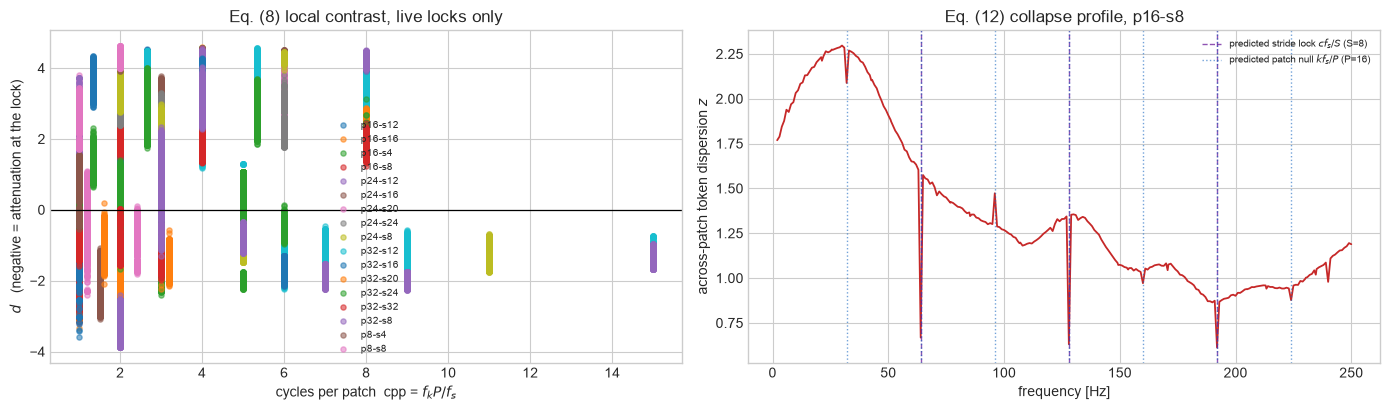

,model,P,S,mode,n_sites,f1,delta_hat,fs_over_S,fs_over_P
6,p16-s12,16,12,kernelsynth,4,42.67,42.67,42.67,32.0
7,p16-s12,16,12,kernelsynth,0,NaN,NaN,42.67,32.0
14,p16-s12,16,12,pure,4,42.67,42.67,42.67,32.0
15,p16-s12,16,12,pure,0,NaN,NaN,42.67,32.0
22,p16-s12,16,12,tsmixup,4,42.67,42.67,42.67,32.0
...,...,...,...,...,...,...,...,...,...
391,p8-s8,8,8,kernelsynth,0,NaN,NaN,64.00,64.0
398,p8-s8,8,8,pure,0,NaN,NaN,64.00,64.0
399,p8-s8,8,8,pure,0,NaN,NaN,64.00,64.0
406,p8-s8,8,8,tsmixup,0,NaN,NaN,64.00,64.0


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.2))

# (a) the contrast d against cycles-per-patch, live rows only. d<0 is the localized loss H1 predicts.
live = contrasts[contrasts["live"]].reset_index(drop=True)
for model, g in live.groupby("model"):
    axes[0].scatter(g["cpp"], g["d"], s=14, alpha=.55, label=model)
axes[0].axhline(0, color="k", lw=.9)
axes[0].set_xlabel("cycles per patch  cpp = $f_k P / f_s$")
axes[0].set_ylabel("$d$   (negative = attenuation at the lock)")
axes[0].set_title("Eq. (8) local contrast, live locks only"); axes[0].legend(fontsize=7)

# (b) the collapse profile of one geometry, with both competing grids drawn on it
sub = collapse[(collapse["model"] == "p16-s8") & (collapse["mode"] == "tsmixup")]
if len(sub) == 0:
    sub = collapse[collapse["model"] == collapse["model"].iloc[0]]
prof = sub.groupby("f", as_index=False)["z"].mean().sort_values("f")
P0, S0 = int(sub["P"].iloc[0]), int(sub["S"].iloc[0])
axes[1].plot(prof["f"], prof["z"], color="#c62828", lw=1.3)
for j, f in enumerate(pl.stride_locks(S0)):
    axes[1].axvline(f, color="#6a1b9a", ls="--", lw=1, alpha=.75,
                    label=f"predicted stride lock $c f_s/S$ (S={S0})" if j == 0 else None)
for j, f in enumerate(pl.patch_nulls(P0)):
    axes[1].axvline(f, color="#1565c0", ls=":", lw=1, alpha=.6,
                    label=f"predicted patch null $k f_s/P$ (P={P0})" if j == 0 else None)
axes[1].set_xlabel("frequency [Hz]"); axes[1].set_ylabel("across-patch token dispersion $z$")
axes[1].set_title(f"Eq. (12) collapse profile, p{P0}-s{S0}"); axes[1].legend(fontsize=7)

fig.tight_layout(); fig.savefig(FIG_DIR / "P2_raw_data.png", dpi=140, bbox_inches="tight"); plt.show()

display(sites[sites.rep == -1][["model", "P", "S", "mode", "n_sites", "f1", "delta_hat"]]
        .assign(fs_over_S=lambda d: (pl.FS / d["S"]).round(2),
                fs_over_P=lambda d: (pl.FS / d["P"]).round(2)).round(2))

---
# Part 3, The likelihood

Part 1 fixed the priors; Part 2 produced the observations. This part supplies the third ingredient
and, more importantly, **checks that it works before it is trusted**.

Three things happen here:

1. **§3.1, the likelihood, written out.** The Student-$t_4$ density that Eq. (9) prescribes is
   implemented directly in NumPy and checked against SciPy. Seeing it as an explicit function makes
   concrete what the sampler is otherwise doing invisibly, and shows *why* $t_4$ rather than a
   Gaussian: its tails make a handful of extreme contrasts cost far less, so the population effect
   is not dragged around by them.
2. **§3.2, the five models.** Each is a small factory function returning a PyMC model.
3. **§3.3, parameter recovery.** The likelihood is used to *simulate* contrasts with a known
   effect on the real design matrix, and the model is refitted. If a known $\log 0.5$ cannot be
   recovered from this design, no posterior fitted on the real data means anything.

## 3.1, The Student-$t_4$ contrast likelihood

For observation $i$ with linear predictor $\mu_i$ and scale $\sigma$,

$$\log p(d_i \mid \mu_i, \sigma, \nu) = \log\Gamma\!\Big(\tfrac{\nu+1}{2}\Big) - \log\Gamma\!\Big(\tfrac{\nu}{2}\Big) - \tfrac12\log(\pi\nu) - \log\sigma - \tfrac{\nu+1}{2}\log\!\Big(1 + \tfrac{(d_i-\mu_i)^2}{\nu\sigma^2}\Big).$$

The last term is the whole point. A Gaussian charges a residual quadratically, so one contrast ten
scale units away costs 50 units of log-likelihood and the fit will contort itself to reduce it. The
$t_4$ charges it logarithmically, about 5 units, so an outlier is *tolerated* rather than
obeyed. With recovery ratios that can collapse to ~0 at a dead frequency, that robustness is not a
stylistic preference; it is what keeps a handful of dead cells from setting $\bar\beta$.

PART 3, LIKELIHOOD
student_t_logpdf matches scipy.stats.t.logpdf to machine precision


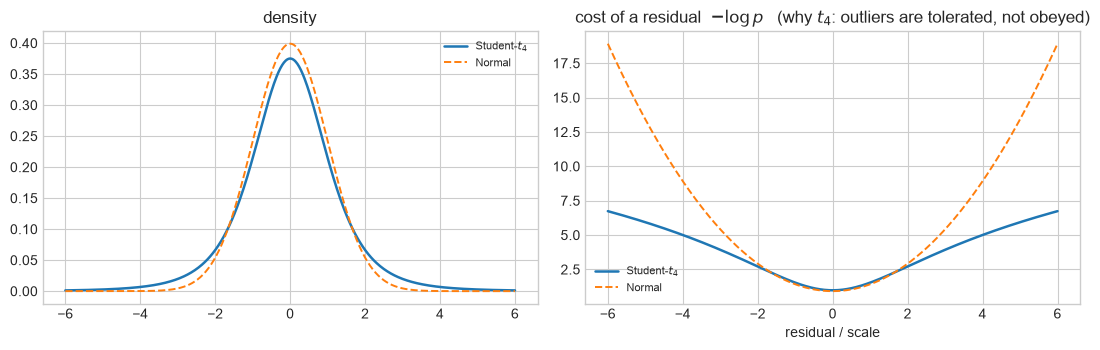

In [17]:
banner("PART 3, LIKELIHOOD")

from scipy.special import gammaln

def student_t_logpdf(d, mu, sigma, nu=NU):
    """Log density of Student-t(nu, mu, sigma), written out rather than imported."""
    z2 = ((np.asarray(d) - mu) / sigma) ** 2
    return (gammaln((nu + 1) / 2) - gammaln(nu / 2) - 0.5 * np.log(np.pi * nu)
            - np.log(sigma) - (nu + 1) / 2 * np.log1p(z2 / nu))

# cross-check against SciPy: the two must agree to machine precision
_d = np.linspace(-6, 6, 501)
assert np.allclose(student_t_logpdf(_d, 0.3, 0.7), stats.t.logpdf(_d, NU, loc=0.3, scale=0.7))
print("student_t_logpdf matches scipy.stats.t.logpdf to machine precision")

fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
ax[0].plot(_d, np.exp(student_t_logpdf(_d, 0, 1)), label=r"Student-$t_4$", lw=1.8)
ax[0].plot(_d, stats.norm.pdf(_d), label="Normal", lw=1.4, ls="--")
ax[0].set_title("density"); ax[0].legend(fontsize=8)
ax[1].plot(_d, -student_t_logpdf(_d, 0, 1), label=r"Student-$t_4$", lw=1.8)
ax[1].plot(_d, -stats.norm.logpdf(_d), label="Normal", lw=1.4, ls="--")
ax[1].set_title("cost of a residual  $-\\log p$   (why $t_4$: outliers are tolerated, not obeyed)")
ax[1].legend(fontsize=8); ax[1].set_xlabel("residual / scale")
fig.tight_layout(); fig.savefig(FIG_DIR / "P3_likelihood.png", dpi=140, bbox_inches="tight"); plt.show()

### The likelihood is what makes the effect identifiable

A quick profile makes the point that Part 1's prior predictive could not: holding the nuisance
parameters at sensible values and sweeping $\bar\beta$, the observed contrasts pick out a narrow
range. The prior was flat over a factor of ~3; the likelihood is not.

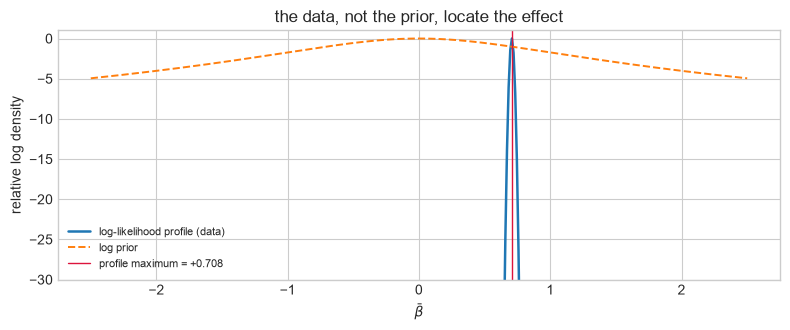

In [18]:
d_live = live["d"].to_numpy()
grid_b = np.linspace(-2.5, 2.5, 400)
ll = np.array([student_t_logpdf(d_live, b, np.std(d_live)).sum() for b in grid_b])
prior_ll = stats.t.logpdf(grid_b, NU, scale=PRIOR_SCALE)

fig, ax = plt.subplots(figsize=(8, 3.4))
ax.plot(grid_b, ll - ll.max(), label="log-likelihood profile (data)", lw=1.8)
ax.plot(grid_b, prior_ll - prior_ll.max(), label="log prior", lw=1.4, ls="--")
ax.axvline(grid_b[ll.argmax()], color="crimson", lw=1,
           label=f"profile maximum = {grid_b[ll.argmax()]:+.3f}")
ax.set_xlabel(r"$\bar\beta$"); ax.set_ylabel("relative log density"); ax.set_ylim(-30, 1)
ax.legend(fontsize=8); ax.set_title("the data, not the prior, locate the effect")
fig.tight_layout(); fig.savefig(FIG_DIR / "P3_profile.png", dpi=140, bbox_inches="tight"); plt.show()

## 3.2, The five PyMC models

Each factory takes a dataframe and returns a model. Two implementation notes that matter for the
sampler rather than for the statistics:

* **Non-centred parameterisation.** Group effects are written $u = \sigma_u z$ with
  $z\sim\mathcal N(0,1)$ rather than $u\sim\mathcal N(0,\sigma_u)$. The two are the same
  distribution, but the first gives NUTS a geometry without the funnel that produces divergences
  when a group scale is small, which it will be here if H2 holds.
* **`log_likelihood=True`.** Pointwise log-likelihoods are stored so that Part 4 and Part 5 can run
  leave-one-out comparisons, which is how the deliverable compares competing hypotheses instead of
  running null-hypothesis tests.

In [19]:
def _codes(series):
    """Integer codes plus the ordered level names, for PyMC `coords`."""
    codes, levels = pd.factorize(series)
    return np.asarray(codes), list(map(str, levels))


def _overlap_scaled(df: pd.DataFrame, cfg_levels: list[str]) -> np.ndarray:
    """Centred, scaled patch overlap O = (P-S)/P; one unit = 0.5 of overlap."""
    O = df.groupby("model")["overlap"].first().reindex(cfg_levels).to_numpy(float)
    return (O - O.mean()) / 0.5


def _logP_centred(df: pd.DataFrame, cfg_levels: list[str]) -> np.ndarray:
    """Centred log patch size.

    deliverable2.tex, H1: "The overlap enters as a ratio and the patch size as log P, because the
    patch grid has spacing fs/P: equal steps in log P are then equal ratios of spacing." On a raw-P
    scale one coefficient would make 8->16 and 16->24 the same change, which the geometry does not.
    """
    Pv = df.groupby("model")["P"].first().reindex(cfg_levels).to_numpy(float)
    lp = np.log(Pv)
    return lp - lp.mean()


# --------------------------------------------------------------------------------------- #
def model_A_contrast(df: pd.DataFrame, scale: float = PRIOR_SCALE, nu: int = NU,
                     likelihood: str = "student", config_level: str = "both") -> pm.Model:
    """Model A, H1 behavioural, and the configuration level that carries M1.

        d_i ~ Student-t(nu, mu_i, sigma)
        mu_i = beta[config_i] + u_harm[i] + u_bg[i]
        beta_c ~ Normal(beta_bar + delta_O * Otilde_c + delta_P * logPtilde_c, tau)

    `config_level` selects which covariates the configuration level carries, which is how M1 is
    decided: deliverable2.tex asks "whether what varies between geometries is the overlap ratio,
    the absolute stride, or the patch size", and the four fits below are compared by LOO.

        "both"     beta_bar + delta_O * Otilde + delta_P * logPtilde   (the reported model)
        "overlap"  beta_bar + delta_O * Otilde
        "patch"    beta_bar + delta_P * logPtilde
        "none"     beta_bar

    `likelihood="normal"` swaps in a Gaussian for the Part 5 robustness check.
    """
    cfg_c, cfg_l = _codes(df["model"])
    harm_c, harm_l = _codes(df["f_lock"].round(3).astype(str))
    bg_c, bg_l = _codes(df["generator"] + "#" + df["bg_id"].astype(str))
    O_t = _overlap_scaled(df, cfg_l)
    lP_t = _logP_centred(df, cfg_l)
    y = df["d"].to_numpy(float)

    coords = {"config": cfg_l, "harmonic": harm_l, "background": bg_l, "obs": np.arange(len(y))}
    with pm.Model(coords=coords) as m:
        #, population level: the estimand of H1 -------------------------------------
        beta_bar = pm.StudentT("beta_bar", nu=nu, mu=0.0, sigma=scale)
        cfg_mean = beta_bar
        if config_level in ("both", "overlap"):
            delta_O = pm.StudentT("delta_O", nu=nu, mu=0.0, sigma=scale)   # M1
            cfg_mean = cfg_mean + delta_O * O_t
        if config_level in ("both", "patch"):
            delta_P = pm.StudentT("delta_P", nu=nu, mu=0.0, sigma=scale)
            cfg_mean = cfg_mean + delta_P * lP_t

        #, hierarchy: configuration, lock harmonic, background realisation ----------
        tau = pm.HalfStudentT("tau", nu=nu, sigma=scale)
        z_cfg = pm.Normal("z_cfg", 0.0, 1.0, dims="config")          # non-centred
        beta = pm.Deterministic("beta", cfg_mean + tau * z_cfg, dims="config")

        sigma_h = pm.HalfStudentT("sigma_harm", nu=nu, sigma=scale)
        u_h = pm.Deterministic("u_harm", sigma_h * pm.Normal("z_harm", 0.0, 1.0, dims="harmonic"),
                               dims="harmonic")
        sigma_b = pm.HalfStudentT("sigma_bg", nu=nu, sigma=scale)
        u_b = pm.Deterministic("u_bg", sigma_b * pm.Normal("z_bg", 0.0, 1.0, dims="background"),
                               dims="background")

        mu = beta[cfg_c] + u_h[harm_c] + u_b[bg_c]
        sigma = pm.HalfStudentT("sigma", nu=nu, sigma=scale)
        if likelihood == "normal":
            pm.Normal("d", mu=mu, sigma=sigma, observed=y, dims="obs")
        else:
            pm.StudentT("d", nu=nu, mu=mu, sigma=sigma, observed=y, dims="obs")

        # reported on the natural scale: the multiplicative change in recovery at a lock
        pm.Deterministic("recovery_ratio", pm.math.exp(beta_bar))
    return m


# --------------------------------------------------------------------------------------- #
def model_B_codelength(df: pd.DataFrame, adjusted: bool = True) -> pm.Model:
    """Model B, H1 representational.  Deliverable Eq. (10).

        y_i ~ Gamma(shape=k, mean=mu_i),   log mu_i = alpha_0 + theta_lock * IsLocked

    `adjusted=True` adds zero-mean stage and geometry offsets. Eq. (10) taken literally pools
    codelengths from probe stages whose scales differ several-fold, which inflates the residual
    without touching the estimand; blocking on stage is the standard remedy and leaves theta_lock
    exactly as specified. The two versions are compared by LOO in Part 4.
    """
    y = np.clip(df["L_bits"].to_numpy(float), 1e-3, None)    # Gamma support is strictly positive
    locked = df["is_locked"].to_numpy(float)
    st_c, st_l = _codes(df["stage"])
    mo_c, mo_l = _codes(df["model"])

    coords = {"stage": st_l, "geometry": mo_l, "obs": np.arange(len(y))}
    with pm.Model(coords=coords) as m:
        alpha0 = pm.Normal("alpha_0", mu=float(np.log(np.mean(y))), sigma=1.0)
        theta = pm.Normal("theta_lock", mu=0.0, sigma=0.5)       # the estimand
        k = pm.Gamma("k", alpha=2.0, beta=0.1)                   # Gamma shape (dispersion)

        log_mu = alpha0 + theta * locked
        if adjusted:
            s_st = pm.HalfNormal("sigma_stage", 1.0)
            s_mo = pm.HalfNormal("sigma_geometry", 1.0)
            eff_st = pm.Deterministic("eff_stage", s_st * pm.Normal("z_stage", 0, 1, dims="stage"),
                                      dims="stage")
            eff_mo = pm.Deterministic("eff_geometry",
                                      s_mo * pm.Normal("z_geometry", 0, 1, dims="geometry"),
                                      dims="geometry")
            log_mu = log_mu + eff_st[st_c] + eff_mo[mo_c]

        mu = pm.math.exp(log_mu)
        pm.Gamma("y", alpha=k, beta=k / mu, observed=y, dims="obs")
        pm.Deterministic("codelength_ratio", pm.math.exp(theta))
    return m


# --------------------------------------------------------------------------------------- #
N_PHASE_BINS = 8       # how many equal slices of the phase circle get their own offset

def model_C_phase(df: pd.DataFrame, with_phase: bool = True, scale: float = PRIOR_SCALE,
                  nu: int = NU) -> pm.Model:
    """Model C, H2.  Does the lock deficit depend on WHERE in its cycle the signal starts?

        y_i = log(R_ctrl + .01) - log(R_lock + .01)          (the deficit; = -d)
        E[y_i] = beta[config] + u_harm + u_phase[bin of phi_i]
        u_phase ~ Normal(0, sigma_phase)

    The phase circle is cut into N_PHASE_BINS equal slices and each slice gets its own offset.
    `sigma_phase` is then the spread of those offsets: how much the deficit moves as the signal
    slides through its cycle. H2 says the deficit is a property of the stride/patch geometry, not
    of the signal's phase, i.e. sigma_phase ~ 0.

    This replaced a first-harmonic (a cos phi + b sin phi) formulation. The variance component is
    easier to state and to defend, it is the direct Bayesian counterpart of the phase spread the
    project's frequentist suite already reports, and it is strictly more general: it catches ANY
    dependence on phase, not only a sinusoidal one.

    `with_phase=False` builds the nested null with no phase term, for the LOO comparison.
    """
    cfg_c, cfg_l = _codes(df["model"])
    harm_c, harm_l = _codes(df["f_lock"].round(3).astype(str))
    # the background realisation (generator + draw) is a grouping factor here exactly as in Model A:
    # without it, variation between TSMixup and KernelSynth backgrounds would be pushed into the
    # residual and could inflate or mask the phase term this model exists to measure
    bg_c, bg_l = _codes(df["generator"] + "#" + df["bg_id"].astype(str))
    # phase matters only modulo 2*pi: it is the tone's alignment with the patch grid
    phi = np.mod(df["phase"].to_numpy(float), 2 * np.pi)
    bin_c = np.floor(phi / (2 * np.pi / N_PHASE_BINS)).astype(int)
    bin_l = [f"{j * 360 // N_PHASE_BINS}-{(j + 1) * 360 // N_PHASE_BINS} deg" for j in range(N_PHASE_BINS)]
    y = df["y_deficit"].to_numpy(float)

    coords = {"config": cfg_l, "harmonic": harm_l, "background": bg_l, "phasebin": bin_l,
              "obs": np.arange(len(y))}
    with pm.Model(coords=coords) as m:
        beta_bar = pm.StudentT("beta_bar", nu=nu, mu=0.0, sigma=scale)
        tau = pm.HalfStudentT("tau", nu=nu, sigma=scale)
        beta = pm.Deterministic("beta", beta_bar + tau * pm.Normal("z_cfg", 0, 1, dims="config"),
                                dims="config")
        sigma_h = pm.HalfStudentT("sigma_harm", nu=nu, sigma=scale)
        u_h = pm.Deterministic("u_harm", sigma_h * pm.Normal("z_harm", 0, 1, dims="harmonic"),
                               dims="harmonic")
        sigma_b = pm.HalfStudentT("sigma_bg", nu=nu, sigma=scale)
        u_b = pm.Deterministic("u_bg", sigma_b * pm.Normal("z_bg", 0, 1, dims="background"),
                               dims="background")

        mu = beta[cfg_c] + u_h[harm_c] + u_b[bg_c]
        if with_phase:
            # the estimand: the spread of the per-phase offsets
            sigma_phase = pm.HalfNormal("sigma_phase", 0.25)
            u_p = pm.Deterministic("u_phase",
                                   sigma_phase * pm.Normal("z_phase", 0, 1, dims="phasebin"),
                                   dims="phasebin")
            mu = mu + u_p[bin_c]

        sigma = pm.HalfStudentT("sigma", nu=nu, sigma=scale)
        pm.StudentT("y", nu=nu, mu=mu, sigma=sigma, observed=y, dims="obs")
    return m


# --------------------------------------------------------------------------------------- #
COMB_FLOOR = 1e-2      # z_norm floor before the log; see the note in §4.4
GRID_TOL_HZ = 1.0      # how close to a predicted site counts as "on the grid"

def model_D1_sites(df: pd.DataFrame, grid: str) -> pm.Model:
    """Model D1, H3 location.  Deliverable Eq. (12).

        log z_g(f) ~ Normal(alpha_g + theta_S 1[f on stride grid] + theta_P 1[f on patch grid], sigma)

    Each frequency is labelled by which predicted grid it falls on (within GRID_TOL_HZ), and the
    model asks whether the token dispersion is systematically lower there. H3 predicts theta_S < 0.

    `grid` selects the labelling: "both" keeps both indicators (the model H3 states), "stride" only
    c*fs/S, "patch" only k*fs/P, "none" neither. The four are fitted on identical observations and
    compared by LOO,
    which is what identifies WHICH parameter generates the sites, the S<P configurations are the
    ones that separate the two families, since on the P=S diagonal the grids coincide.

    This is deliberately the same shape of model as Eq. (10): a linear predictor on a log scale
    with an indicator variable. It replaced an earlier Gaussian-dip "comb" likelihood with free
    depth and width, which estimated two nuisance quantities nothing downstream used and was far
    harder to justify than the claim it was testing.
    """
    g_c, g_l = _codes(df["model"])
    logz = np.log(np.clip(df["z_norm"].to_numpy(float), COMB_FLOOR, None))

    # membership indicators, built from the same helper that defines the grids everywhere else
    on_stride = np.zeros(len(df))
    on_patch = np.zeros(len(df))
    for gi, _name in enumerate(g_l):
        sel = g_c == gi
        P = int(df.loc[sel, "P"].iloc[0]); S = int(df.loc[sel, "S"].iloc[0])
        f = df.loc[sel, "f"].to_numpy(float)
        on_stride[sel] = (pl.comb_distance(f, pl.FS / S) <= GRID_TOL_HZ).astype(float)
        on_patch[sel] = (pl.comb_distance(f, pl.FS / P) <= GRID_TOL_HZ).astype(float)

    coords = {"geometry": g_l, "obs": np.arange(len(logz))}
    with pm.Model(coords=coords) as m:
        alpha_g = pm.Normal("alpha_g", 0.0, 1.0, dims="geometry")   # off-grid level per geometry
        sigma = pm.HalfNormal("sigma", 1.0)
        mu = alpha_g[g_c]
        if grid in ("stride", "both"):
            theta_S = pm.Normal("theta_S", 0.0, 1.0)
            mu = mu + theta_S * on_stride
        if grid in ("patch", "both"):
            theta_P = pm.Normal("theta_P", 0.0, 1.0)
            mu = mu + theta_P * on_patch
        pm.Normal("logz", mu=mu, sigma=sigma, observed=logz, dims="obs")
    return m


# --------------------------------------------------------------------------------------- #
def model_D2_movement(df: pd.DataFrame, branch: str, resolution_hz: float | None = None,
                      response: str = "f1") -> pm.Model:
    """Models D2, H3a and H3b.  One scaling law per branch, no intercept.

        f1_hat[g] ~ Normal(kappa_F * Delta_F[g], sqrt(sigma_F^2 + df^2))

    deliverable2.tex, H3: every detected dip is first assigned to the branch that predicts it and
    ambiguous sites are set aside, then the fundamental of that branch is compared with the spacing
    that branch predicts, Delta_S = fs/S or Delta_P = fs/P. H3a predicts kappa_S = 1 and H3b
    predicts kappa_P = 1: each branch tracks its own parameter one for one.

    This replaced a single regression of one pooled spacing on BOTH predictors, with an intercept
    and the prediction kappa_P = 0. That formulation contradicted H3 as approved in Deliverable 1,
    which claims that each branch moves with its own parameter; and it treated the detected set as
    one comb, when F_lock is a union and the union of two combs has two interlaced spacings. The
    dip that formulation had to call spurious at p16-s8 is a patch null at fs/P = 32 Hz, i.e. an
    observation H3 predicts.

    **Measurement resolution.** The spacing is read off a frequency sweep, so it carries a floor of
    about one grid step whatever the sampling noise. Stating it is not cosmetic: when the sites land
    on the predicted comb exactly, the residuals vanish, sigma is pushed to zero and the posterior
    develops a funnel NUTS cannot traverse (R-hat above 2, hundreds of divergences). Adding the
    floor in quadrature removes the pathology and is the honest statement: a near-zero sigma is then
    a result, the spacings follow the law to within the sweep resolution, not a sampler failure.

    `response="f1"` uses the branch's fundamental, the lowest detected site of that branch, which is
    what the deliverable specifies. `response="delta_hat"` uses the median gap of the same branch and
    is fitted only as a robustness check: with three or four sites in band one spurious detection
    inserts a short interval and flips the median, to which the fundamental is immune.
    """
    sub = df[df["branch"] == branch]
    y = sub[response].to_numpy(float)                      # measured spacing [Hz]
    x = sub["predicted_spacing"].to_numpy(float)           # fs/S or fs/P [Hz]
    name = {"stride": "kappa_S", "patch": "kappa_P"}[branch]

    step = resolution_hz if resolution_hz is not None else CFG.collapse_step
    with pm.Model(coords={"obs": np.arange(len(y))}) as m:
        kappa = pm.Normal(name, mu=0.0, sigma=1.0)         # H3a / H3b predict 1
        sigma_d = pm.HalfNormal("sigma_extra", 5.0)        # scatter beyond the grid floor [Hz]
        sigma_total = pm.math.sqrt(sigma_d ** 2 + step ** 2)
        pm.Normal("f1_hat", mu=kappa * x, sigma=sigma_total, observed=y, dims="obs")
    return m


def sample(model, name: str, draws=None, tune=None, chains=None, **kw):
    """One place for the sampler settings the deliverable's Inference paragraph prescribes.

    `NUTS_BACKEND` (set in Part 0.3) selects who does the sampling. The model, the priors and the
    number of draws are identical in every case; only the implementation of NUTS changes, so the
    posterior is the same target distribution.

      "pymc"     the default. Pure Python/PyTensor, CPU only.
      "nutpie"   a Rust implementation, several times faster on the same CPU.
      "numpyro"  JAX. This is the one that uses a GPU, and the only reason a GPU runtime helps:
                 PyMC's own sampler never touches it. Chains run vectorised rather than in series.
    """
    extra = dict(kw)
    if NUTS_BACKEND != "pymc":
        extra["nuts_sampler"] = NUTS_BACKEND
        if NUTS_BACKEND == "numpyro":
            extra.setdefault("nuts_sampler_kwargs", {"chain_method": "vectorized"})
    with model:
        return pm.sample(draws=draws or DRAWS, tune=tune or TUNE, chains=chains or CHAINS,
                         cores=4, random_seed=SEED, target_accept=TARGET_ACCEPT,
                         progressbar=False, idata_kwargs={"log_likelihood": True}, **extra)

print("model factories ready: A (H1 behavioural + M1), B (H1 representational), "
      "C (H2), D1 (H3 location), D2 (H3a stride branch, H3b patch branch)")

model factories ready: A (H1 behavioural + M1), B (H1 representational), C (H2), D1 (H3 location), D2 (H3a stride branch, H3b patch branch)


## 3.3, Parameter recovery: can this design see an effect that is really there?

A posterior centred on zero has two possible readings: there is no effect, or the design cannot see
one. The two are distinguished *before* looking at the real posterior, by simulating contrasts on
the **real design matrix** with a known $\bar\beta$ and refitting.

Four truths are used, spanning the range the deliverable cares about: no effect, 20% attenuation
(the reporting threshold), 50%, and 90%. Recovery is judged by whether the 95% credible interval
covers the truth and by how much the posterior has narrowed relative to the prior.

In [20]:
def simulate_from_A(df: pd.DataFrame, beta_true: float, seed: int = SEED) -> pd.DataFrame:
    """Replace the observed d with data simulated from Model A at a known population effect."""
    rng = np.random.default_rng(seed)
    out = df.copy()
    cfg_c, cfg_l = _codes(out["model"])
    harm_c, harm_l = _codes(out["f_lock"].round(3).astype(str))
    bg_c, bg_l = _codes(out["generator"] + "#" + out["bg_id"].astype(str))
    # modest but non-zero group structure, so recovery is not tested on an unrealistically clean design
    u_cfg = rng.normal(0, 0.15, len(cfg_l))
    u_h = rng.normal(0, 0.20, len(harm_l))
    u_b = rng.normal(0, 0.10, len(bg_l))
    mu = beta_true + u_cfg[cfg_c] + u_h[harm_c] + u_b[bg_c]
    out["d"] = mu + 0.30 * stats.t.rvs(NU, size=len(out), random_state=rng.integers(1 << 31))
    return out


TRUTHS = {"no effect": 0.0, "20% attenuation": np.log(0.8),
          "50% attenuation": np.log(0.5), "90% attenuation": np.log(0.1)}

if have("03_recovery.parquet"):
    recovery_tbl = load_df("03_recovery.parquet")
else:
    rec_rows = []
    for label, truth in TRUTHS.items():
        sim_df = simulate_from_A(live, truth)
        idata = sample(model_A_contrast(sim_df), f"recovery_{label}",
                       draws=max(400, DRAWS // 2), tune=max(400, TUNE // 2), chains=2)
        post = idata.posterior["beta_bar"].values.ravel()
        lo, hi = np.quantile(post, [0.025, 0.975])
        rec_rows.append(dict(scenario=label, true_beta=truth, posterior_median=float(np.median(post)),
                             hdi_lo=float(lo), hdi_hi=float(hi), covers_truth=bool(lo <= truth <= hi),
                             posterior_sd=float(post.std()), prior_sd=float(PRIOR_SCALE * np.sqrt(NU / (NU - 2))),
                             divergences=int(idata.sample_stats["diverging"].values.sum())))
    recovery_tbl = save_df(pd.DataFrame(rec_rows), "03_recovery.parquet")

recovery_tbl["shrinkage"] = (1 - recovery_tbl["posterior_sd"] / recovery_tbl["prior_sd"]).round(3)
display(recovery_tbl.round(4))

if recovery_tbl["covers_truth"].all():
    print("\nPARAMETER RECOVERY PASSED: every 95% credible interval covers its known effect, and the "
          "posterior is far narrower than the prior. A near-zero posterior on the real data can "
          "therefore be read as 'no effect', not as 'this design is blind'.")
else:
    bad = recovery_tbl[~recovery_tbl["covers_truth"]]["scenario"].tolist()
    print(f"\nPARAMETER RECOVERY FAILED for {bad}, do not interpret Part 4 until this is resolved.")

  checkpoint <- 03_recovery.parquet


,scenario,true_beta,posterior_median,hdi_lo,hdi_hi,covers_truth,posterior_sd,prior_sd,divergences,shrinkage
0,no effect,0.0000,0.0227,-0.0947,0.1046,True,0.0522,0.7071,0,0.926
1,20% attenuation,-0.2231,-0.2208,-0.3262,-0.1104,True,0.0558,0.7071,0,0.921
2,50% attenuation,-0.6931,-0.6983,-0.8195,-0.5997,True,0.0494,0.7071,0,0.930
3,90% attenuation,-2.3026,-2.2606,-2.3586,-2.1684,True,0.0467,0.7071,0,0.934



PARAMETER RECOVERY PASSED: every 95% credible interval covers its known effect, and the posterior is far narrower than the prior. A near-zero posterior on the real data can therefore be read as 'no effect', not as 'this design is blind'.


---
# Part 4, Posterior inference

Priors are fixed, the data are in, the likelihood is validated. This part fits the five models and
reports, for each, what the deliverable's *Inference* paragraph asks for: the effect on its natural
scale with a 95% credible interval, the posterior probability of the preregistered threshold, and,
where two formulations compete, a leave-one-out comparison rather than a null-hypothesis test.

Every fit is checkpointed individually, so a disconnect costs at most one model.

In [21]:
banner("PART 4, POSTERIOR INFERENCE")

def report(idata, var: str, transform=None, label: str = "") -> dict:
    """Posterior median + 95% credible interval for one parameter, on its natural scale."""
    x = idata.posterior[var].values.ravel()
    if transform is not None:
        x = transform(x)
    lo, hi = np.quantile(x, [0.025, 0.975])
    print(f"  {label or var:<24s} median {np.median(x):+.4f}   95% CrI [{lo:+.4f}, {hi:+.4f}]")
    return dict(parameter=label or var, median=float(np.median(x)),
                lo=float(lo), hi=float(hi), sd=float(x.std()))

def prob(idata, var: str, condition) -> float:
    return float(np.mean(condition(idata.posterior[var].values.ravel())))

PART 4, POSTERIOR INFERENCE


## 4.1, Model A: H1 at the behavioural level

**Estimand.** $\bar\beta$, the population log-ratio of forecast amplitude recovery at a phase-lock
against its matched controls. $e^{\bar\beta} < 1$ means the lock recovers *less*, which is what H1
predicts.

**Reported.** $e^{\bar\beta}$ with a 95% credible interval; $\Pr(\bar\beta<\log 0.8\mid D)$, the
probability of at least 20% attenuation; and $\Pr(|\bar\beta|<\log 1.1\mid D)$, the probability the
effect is practically nil. The per-configuration $\beta_c$ are shown as a forest plot, because H1
does not have to hold uniformly, and the overlap slope $\delta_O$ says whether it weakens as the
patches overlap more.

  checkpoint <- 04_A.nc

Model A, H1 behavioural
  beta_bar (log ratio)     median +0.0264   95% CrI [-0.3949, +0.6460]
  recovery ratio exp(beta_bar) median +1.0268   95% CrI [+0.6738, +1.9079]
  delta_O (overlap slope, M1) median +0.4525   95% CrI [+0.0108, +0.8213]
  delta_P (log patch-size slope) median -0.5251   95% CrI [-0.9167, -0.1342]

  P(at least 20% attenuation | D) = 0.137   (prior: 0.336)
  P(practically no effect  | D)   = 0.306   (ROPE |beta| < log 1.1)
  P(beta_bar < 0 | D)             = 0.462   (any attenuation at all)
  P(delta_O < 0 | D)              = 0.023   (M1: overlap reduces the deficit)


,mean,sd,eti95_lb,eti95_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
beta_bar,0.1,0.3,-0.39,0.65,6,12,1.63,0.1,0.08
delta_O,0.44,0.2,0.011,0.82,38,47,1.10,0.033,0.024
delta_P,-0.52,0.2,-0.92,-0.13,83,100,1.05,0.022,0.017
tau,0.42,0.07,0.31,0.6,113,166,1.03,0.0072,0.0062
sigma,0.47615,0.00122,0.47,0.48,16247,6259,1.00,9.6e-06,6.8e-06
sigma_harm,1.8,0.22,1.5,2.3,11,16,1.30,0.066,0.047
sigma_bg,0.0085,0.0032,0.0014,0.014,974,866,1.01,0.00011,7.2e-05


  checkpoint <- 04_A_overlap.nc
  checkpoint <- 04_A_patch.nc
  checkpoint <- 04_A_none.nc


,rank,elpd_diff,dse,p_worse,diag_diff,diag_elpd,p,elpd,se,weight
overlap + patch size,0,0.0,0.00,NaN,,,70.4,-137600.0,390.0,1.0
patch size only,1,-0.4,0.13,1.00,|elpd_diff| < 4,,70.1,-137600.0,390.0,0.0
neither,2,-0.4,0.13,1.00,|elpd_diff| < 4,,70.3,-137600.0,390.0,0.0
overlap only,3,-0.5,0.18,0.99,|elpd_diff| < 4,,69.6,-137600.0,390.0,0.0


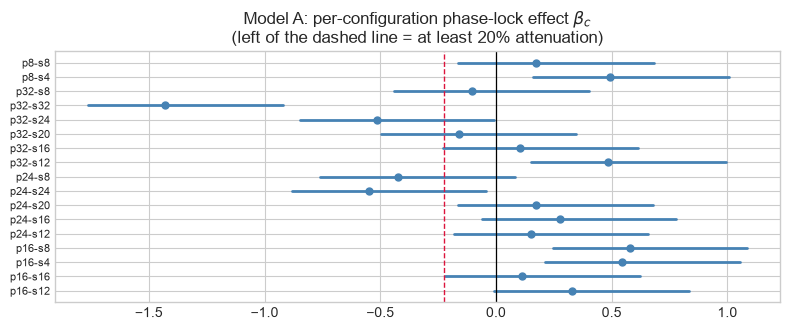

In [22]:
idata_A = cached_fit("04_A.nc", lambda: sample(model_A_contrast(live), "A"))

print("\nModel A, H1 behavioural")
rowsA = [report(idata_A, "beta_bar", label="beta_bar (log ratio)"),
         report(idata_A, "beta_bar", np.exp, label="recovery ratio exp(beta_bar)"),
         report(idata_A, "delta_O", label="delta_O (overlap slope, M1)"),
         report(idata_A, "delta_P", label="delta_P (log patch-size slope)")]
pA_att = prob(idata_A, "beta_bar", lambda x: x < ATTENUATION_20)
pA_rope = prob(idata_A, "beta_bar", lambda x: np.abs(x) < ROPE_LOG)
pA_neg = prob(idata_A, "beta_bar", lambda x: x < 0)
print(f"\n  P(at least 20% attenuation | D) = {pA_att:.3f}   (prior: "
      f"{prior_summary['p_attenuation20_prior']:.3f})")
print(f"  P(practically no effect  | D)   = {pA_rope:.3f}   (ROPE |beta| < log 1.1)")
print(f"  P(beta_bar < 0 | D)             = {pA_neg:.3f}   (any attenuation at all)")

pA_mit = prob(idata_A, "delta_O", lambda x: x < 0)
print(f"  P(delta_O < 0 | D)              = {pA_mit:.3f}   (M1: overlap reduces the deficit)")

display(az.summary(idata_A.posterior, var_names=["beta_bar", "delta_O", "delta_P", "tau", "sigma",
                                       "sigma_harm", "sigma_bg"], ci_prob=0.95).round(3))

# M1, second half: which description of the configuration level does the data prefer?
# deliverable2.tex, Mitigation: "the overlap ratio, the absolute stride, or the patch size".
# idata_A IS the config_level="both" fit (it is the default), so it is reused rather than
# sampled a second time: on the full design that is one avoidable fit of the largest model.
fitsM1 = {"overlap + patch size": idata_A}
fitsM1.update({lbl: cached_fit(f"04_A_{lvl}.nc",
                               lambda l=lvl, n=lbl: sample(model_A_contrast(live, config_level=l), n))
               for lvl, lbl in (("overlap", "overlap only"), ("patch", "patch size only"),
                                ("none", "neither"))})
cmpM1 = az.compare(fitsM1)
display(cmpM1)

# plot_forest: ArviZ 1.x changed the API; draw manually
post_beta = idata_A.posterior["beta"].values.reshape(-1, idata_A.posterior.sizes["config"])
cfg_names = list(idata_A.posterior.coords["config"].values)
fig, ax = plt.subplots(figsize=(8, 3.4))
for j, name in enumerate(cfg_names):
    lo, med, hi = np.quantile(post_beta[:, j], [0.025, 0.5, 0.975])
    ax.plot([lo, hi], [j, j], color="steelblue", lw=2)
    ax.plot(med, j, "o", color="steelblue", ms=5)
ax.axvline(0, color="k", lw=.9)
ax.axvline(ATTENUATION_20, color="crimson", ls="--", lw=1)
ax.set_yticks(range(len(cfg_names))); ax.set_yticklabels(cfg_names, fontsize=8)
ax.set_title("Model A: per-configuration phase-lock effect $\\beta_c$\n"
             "(left of the dashed line = at least 20% attenuation)")
plt.tight_layout(); plt.savefig(FIG_DIR / "P4_A_forest.png", dpi=140, bbox_inches="tight"); plt.show()


## 4.2, Model B: H1 at the representational level

**Estimand.** $\theta_{lock}$, the log-ratio by which the frequency-local prequential codelength
expands at a locked frequency. $e^{\theta_{lock}} > 1$ means the representation needs *more* bits
to separate a locked frequency from its neighbours, information loss in the sense of Voita &
Titov, independent of whether the forecast happens to recover the tone.

This is the second half of the deliverable's original two-part framework, and it can disagree with
Model A. Model A asks whether the forecast rebuilds the tone; Model B asks whether the frequency is
still *readable* inside the network. A lock that is rebuilt but no longer distinguishable from its
neighbours would show up here and nowhere else.

The unadjusted form (Eq. (10) taken literally) is fitted alongside and compared by LOO, so the
blocking decision of §3.2 is reported rather than assumed.

In [23]:
idata_B = cached_fit("04_B.nc", lambda: sample(model_B_codelength(mdl_cells, adjusted=True), "B"))
idata_B0 = cached_fit("04_B_unadjusted.nc",
                      lambda: sample(model_B_codelength(mdl_cells, adjusted=False), "B0"))

print("\nModel B, H1 representational")
rowsB = [report(idata_B, "theta_lock", label="theta_lock (log ratio)"),
         report(idata_B, "theta_lock", np.exp, label="codelength ratio exp(theta_lock)"),
         report(idata_B, "k", label="Gamma shape k")]
pB_exp = prob(idata_B, "theta_lock", lambda x: x > 0)
pB_20 = prob(idata_B, "theta_lock", lambda x: x > np.log(1.2))
pB_rope = prob(idata_B, "theta_lock", lambda x: np.abs(x) < ROPE_LOG)
print(f"\n  P(codelength expands at a lock | D) = {pB_exp:.3f}")
print(f"  P(expansion of at least 20%   | D)   = {pB_20:.3f}")
print(f"  P(practically no effect       | D)   = {pB_rope:.3f}")

display(az.summary(idata_B.posterior, var_names=["alpha_0", "theta_lock", "k"], ci_prob=0.95).round(3))

cmpB = az.compare({"stage+geometry adjusted": idata_B, "Eq. (10) literal": idata_B0})
display(cmpB)
print("\nIf the adjusted model wins decisively, pooling probe stages of very different scale was "
      "indeed inflating the residual; theta_lock is unchanged in meaning either way.")

  checkpoint <- 04_B.nc
  checkpoint <- 04_B_unadjusted.nc

Model B, H1 representational
  theta_lock (log ratio)   median +0.2377   95% CrI [+0.2108, +0.2649]
  codelength ratio exp(theta_lock) median +1.2684   95% CrI [+1.2346, +1.3033]
  Gamma shape k            median +3.5758   95% CrI [+3.4548, +3.6992]

  P(codelength expands at a lock | D) = 1.000
  P(expansion of at least 20%   | D)   = 1.000
  P(practically no effect       | D)   = 0.000


,mean,sd,eti95_lb,eti95_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
alpha_0,4.034,0.086,3.9,4.2,572,786,1.01,0.0036,0.0036
theta_lock,0.2378,0.014,0.21,0.26,7266,5758,1.00,0.00016,0.00011
k,3.576,0.0624,3.5,3.7,10573,5655,1.00,0.00061,0.00042


,rank,elpd_diff,dse,p_worse,diag_diff,diag_elpd,p,elpd,se,weight
stage+geometry adjusted,0,0.0,0.0,NaN,,,26.3,-29300.0,54.0,0.99
Eq. (10) literal,1,-470.0,29.0,1.0,,,2.4,-29790.0,48.0,0.01



If the adjusted model wins decisively, pooling probe stages of very different scale was indeed inflating the residual; theta_lock is unchanged in meaning either way.


## 4.3, Model C: H2, is the deficit set by the geometry or by the phase?

**Estimand.** $\sigma_\phi$, the spread of the per-phase offsets. The phase circle is cut into
eight equal slices, each slice gets its own offset, and $\sigma_\phi$ says how far apart those
offsets are, that is, how much the lock deficit moves as the signal slides through its cycle.

H2 says the deficit is set by the stride/patch alignment and not by where the signal happens to
start, so it predicts $\sigma_\phi \approx 0$. Two readings are reported, answering different
questions:

* $\Pr(\sigma_\phi<\log 1.1\mid D)$, is the phase dependence *practically* negligible? (a
  magnitude question)
* LOO against the model with no phase term at all, does allowing phase to matter *predict better*?
  (an evidential question)

They can disagree, and the disagreement is informative: a small but consistently detected phase
dependence would show a low equivalence probability together with a LOO preference for the phase
model.

  checkpoint <- 04_C.nc
  checkpoint <- 04_C_nophase.nc

Model C, H2 phase invariance
  sigma_phase (spread across phase) median +0.0334   95% CrI [+0.0204, +0.0675]
  beta_bar (deficit, sign-flipped d) median -0.1423   95% CrI [-0.7569, +0.2941]

  P(sigma_phase < log 1.1 | D) = 0.997   (prior: 0.299)


,rank,elpd_diff,dse,p_worse,diag_diff,diag_elpd,p,elpd,se,weight
phase-dependent (H2 refuted),0,0.0,0.0,NaN,,,71.9,-137500.0,390.0,1.0
phase-free (H2 holds),1,-150.0,17.0,1.0,,,70.1,-137600.0,390.0,0.0


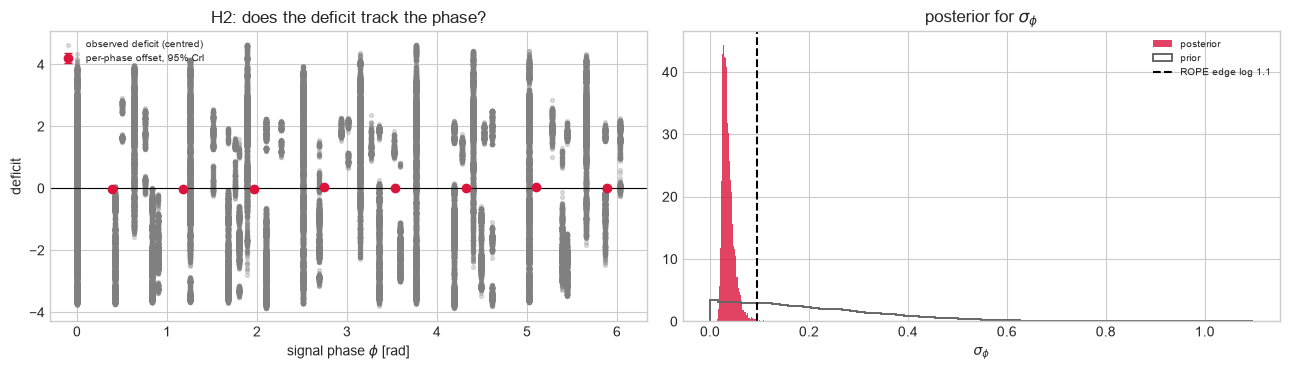

In [24]:
idata_C = cached_fit("04_C.nc", lambda: sample(model_C_phase(live, with_phase=True), "C"))
idata_C0 = cached_fit("04_C_nophase.nc", lambda: sample(model_C_phase(live, with_phase=False), "C0"))

print("\nModel C, H2 phase invariance")
rowsC = [report(idata_C, "sigma_phase", label="sigma_phase (spread across phase)"),
         report(idata_C, "beta_bar", label="beta_bar (deficit, sign-flipped d)")]
pC_rope = prob(idata_C, "sigma_phase", lambda x: x < ROPE_LOG)
print(f"\n  P(sigma_phase < log 1.1 | D) = {pC_rope:.3f}   (prior: "
      f"{prior_summary['p_sigma_phase_in_rope_prior']:.3f})")

cmpC = az.compare({"phase-dependent (H2 refuted)": idata_C, "phase-free (H2 holds)": idata_C0})
display(cmpC)

# the per-phase offsets against the raw deficits they summarise
u_p = idata_C.posterior["u_phase"].values.reshape(-1, N_PHASE_BINS)
lo, med, hi = np.quantile(u_p, [0.025, 0.5, 0.975], axis=0)
centres = (np.arange(N_PHASE_BINS) + 0.5) * (2 * np.pi / N_PHASE_BINS)

fig, ax = plt.subplots(1, 2, figsize=(13, 3.8))
ax[0].scatter(np.mod(live["phase"], 2 * np.pi),
              live["y_deficit"] - live["y_deficit"].mean(), s=8, alpha=.25, color="0.5",
              label="observed deficit (centred)")
ax[0].errorbar(centres, med, yerr=[med - lo, hi - med], fmt="o", color="crimson", capsize=3,
               label="per-phase offset, 95% CrI")
ax[0].axhline(0, color="k", lw=.8); ax[0].set_xlabel(r"signal phase $\phi$ [rad]")
ax[0].set_ylabel("deficit"); ax[0].legend(fontsize=7)
ax[0].set_title("H2: does the deficit track the phase?")

s_post = idata_C.posterior["sigma_phase"].values.ravel()
ax[1].hist(s_post, bins=70, density=True, color="crimson", alpha=.8, label="posterior")
ax[1].hist(sigma_phase_prior, bins=70, density=True, histtype="step", lw=1.4, color="0.4",
           label="prior")
ax[1].axvline(ROPE_LOG, color="k", ls="--", label="ROPE edge log 1.1")
ax[1].set_xlabel(r"$\sigma_\phi$"); ax[1].legend(fontsize=7)
ax[1].set_title(r"posterior for $\sigma_\phi$")
fig.tight_layout(); fig.savefig(FIG_DIR / "P4_C_phase.png", dpi=140, bbox_inches="tight"); plt.show()

## 4.4, Model D1: H3, which parameter generates the degradation sites?

**Estimand.** Not an effect size but a *location law*: is the token dispersion systematically lower
on one of the two predicted grids? Each frequency is labelled by the grid it falls on (within 1 Hz)
and three hypotheses are fitted to the same profiles, then compared by LOO:

* $M_S$, only the stride indicator $\mathbb{1}[f \in \{c f_s/S\}]$;
* $M_P$, only the patch indicator $\mathbb{1}[f \in \{k f_s/P\}]$;
* $M_0$, neither.

H3 predicts $\theta_S < 0$ under $M_S$. The comparison is only meaningful because the sweep grid is
the union of *every* geometry's predicted sites: each model is scored where its rival predicts a dip
as well as where it does. And it is only identified because the design contains configurations with
$S<P$, where the two grids genuinely differ, on the $P=S$ diagonal they coincide by construction
and no amount of data can separate them.

Fitted per signal mode. On a pure sinusoid the dispersion is exactly zero at a lock, so `z_norm` is
floored at `COMB_FLOOR` before the log; the floor bounds how large $|\theta_S|$ can get but affects
$M_S$, $M_P$ and $M_0$ identically, leaving the *comparison*, which is the inference, untouched.

In [25]:
D1 = {}
cmpD1_rows = []
for mode in sorted(collapse["mode"].unique()):
    sub = collapse[collapse["mode"] == mode].reset_index(drop=True)
    fits = {}
    # deliverable2.tex, H3: "the two-label fit should win the leave-one-out comparison against
    # each label alone and against neither", so all four labellings are fitted on the same rows.
    for spacing, label in (("both", "M_SP: both grids (H3)"),
                           ("stride", "M_S : sites on c*fs/S"),
                           ("patch", "M_P : sites on k*fs/P"),
                           ("none", "M_0 : no grid effect")):
        name = f"04_D1_{mode}_{spacing}.nc"
        fits[label] = cached_fit(name, lambda sp=spacing, s=sub: sample(model_D1_sites(s, sp), name))
    D1[mode] = fits
    cmp_ = az.compare(fits)
    cmp_.insert(0, "mode", mode)
    cmpD1_rows.append(cmp_.reset_index().rename(columns={"index": "model"}))
    print(f"\n--- collapse mode: {mode} ---")
    display(cmp_)

cmpD1 = pd.concat(cmpD1_rows, ignore_index=True)
best = cmpD1.sort_values(["mode", "rank"]).groupby("mode").first()[["model", "elpd"]]
print("\nbest model per signal mode (LOO):")
display(best)

  checkpoint <- 04_D1_kernelsynth_both.nc
  checkpoint <- 04_D1_kernelsynth_stride.nc
  checkpoint <- 04_D1_kernelsynth_patch.nc
  checkpoint <- 04_D1_kernelsynth_none.nc



--- collapse mode: kernelsynth ---


,mode,rank,elpd_diff,dse,p_worse,diag_diff,diag_elpd,p,elpd,se,weight
M_S : sites on c*fs/S,kernelsynth,0,0.0,0.0,NaN,,,19.1,-5600.0,63.0,0.44
M_SP: both grids (H3),kernelsynth,1,-1.0,1.1,0.69,|elpd_diff| < 4,,20.2,-5600.0,63.0,0.44
M_P : sites on k*fs/P,kernelsynth,2,-320.0,30.0,1.00,,,18.9,-5900.0,67.0,0.00
M_0 : no grid effect,kernelsynth,3,-410.0,35.0,1.00,,,17.8,-6000.0,69.0,0.12


  checkpoint <- 04_D1_pure_both.nc
  checkpoint <- 04_D1_pure_stride.nc
  checkpoint <- 04_D1_pure_patch.nc
  checkpoint <- 04_D1_pure_none.nc



--- collapse mode: pure ---


...

  checkpoint <- 04_D1_tsmixup_both.nc
  checkpoint <- 04_D1_tsmixup_stride.nc
  checkpoint <- 04_D1_tsmixup_patch.nc
  checkpoint <- 04_D1_tsmixup_none.nc



--- collapse mode: tsmixup ---


,mode,rank,elpd_diff,dse,p_worse,diag_diff,diag_elpd,p,elpd,se,weight
M_S : sites on c*fs/S,tsmixup,0,0.0,0.0,NaN,,,18.9,-4000.0,64.0,0.48
M_SP: both grids (H3),tsmixup,1,-0.0,1.2,0.62,|elpd_diff| < 4,,20.0,-4000.0,64.0,0.44
M_P : sites on k*fs/P,tsmixup,2,-200.0,22.0,1.00,,,18.9,-4200.0,66.0,0.00
M_0 : no grid effect,tsmixup,3,-260.0,25.0,1.00,,,17.8,-4300.0,67.0,0.08



best model per signal mode (LOO):


,model,elpd
mode,,
kernelsynth,M_S : sites on c*fs/S,-5600.0
pure,M_S : sites on c*fs/S,-15200.0
tsmixup,M_S : sites on c*fs/S,-4000.0


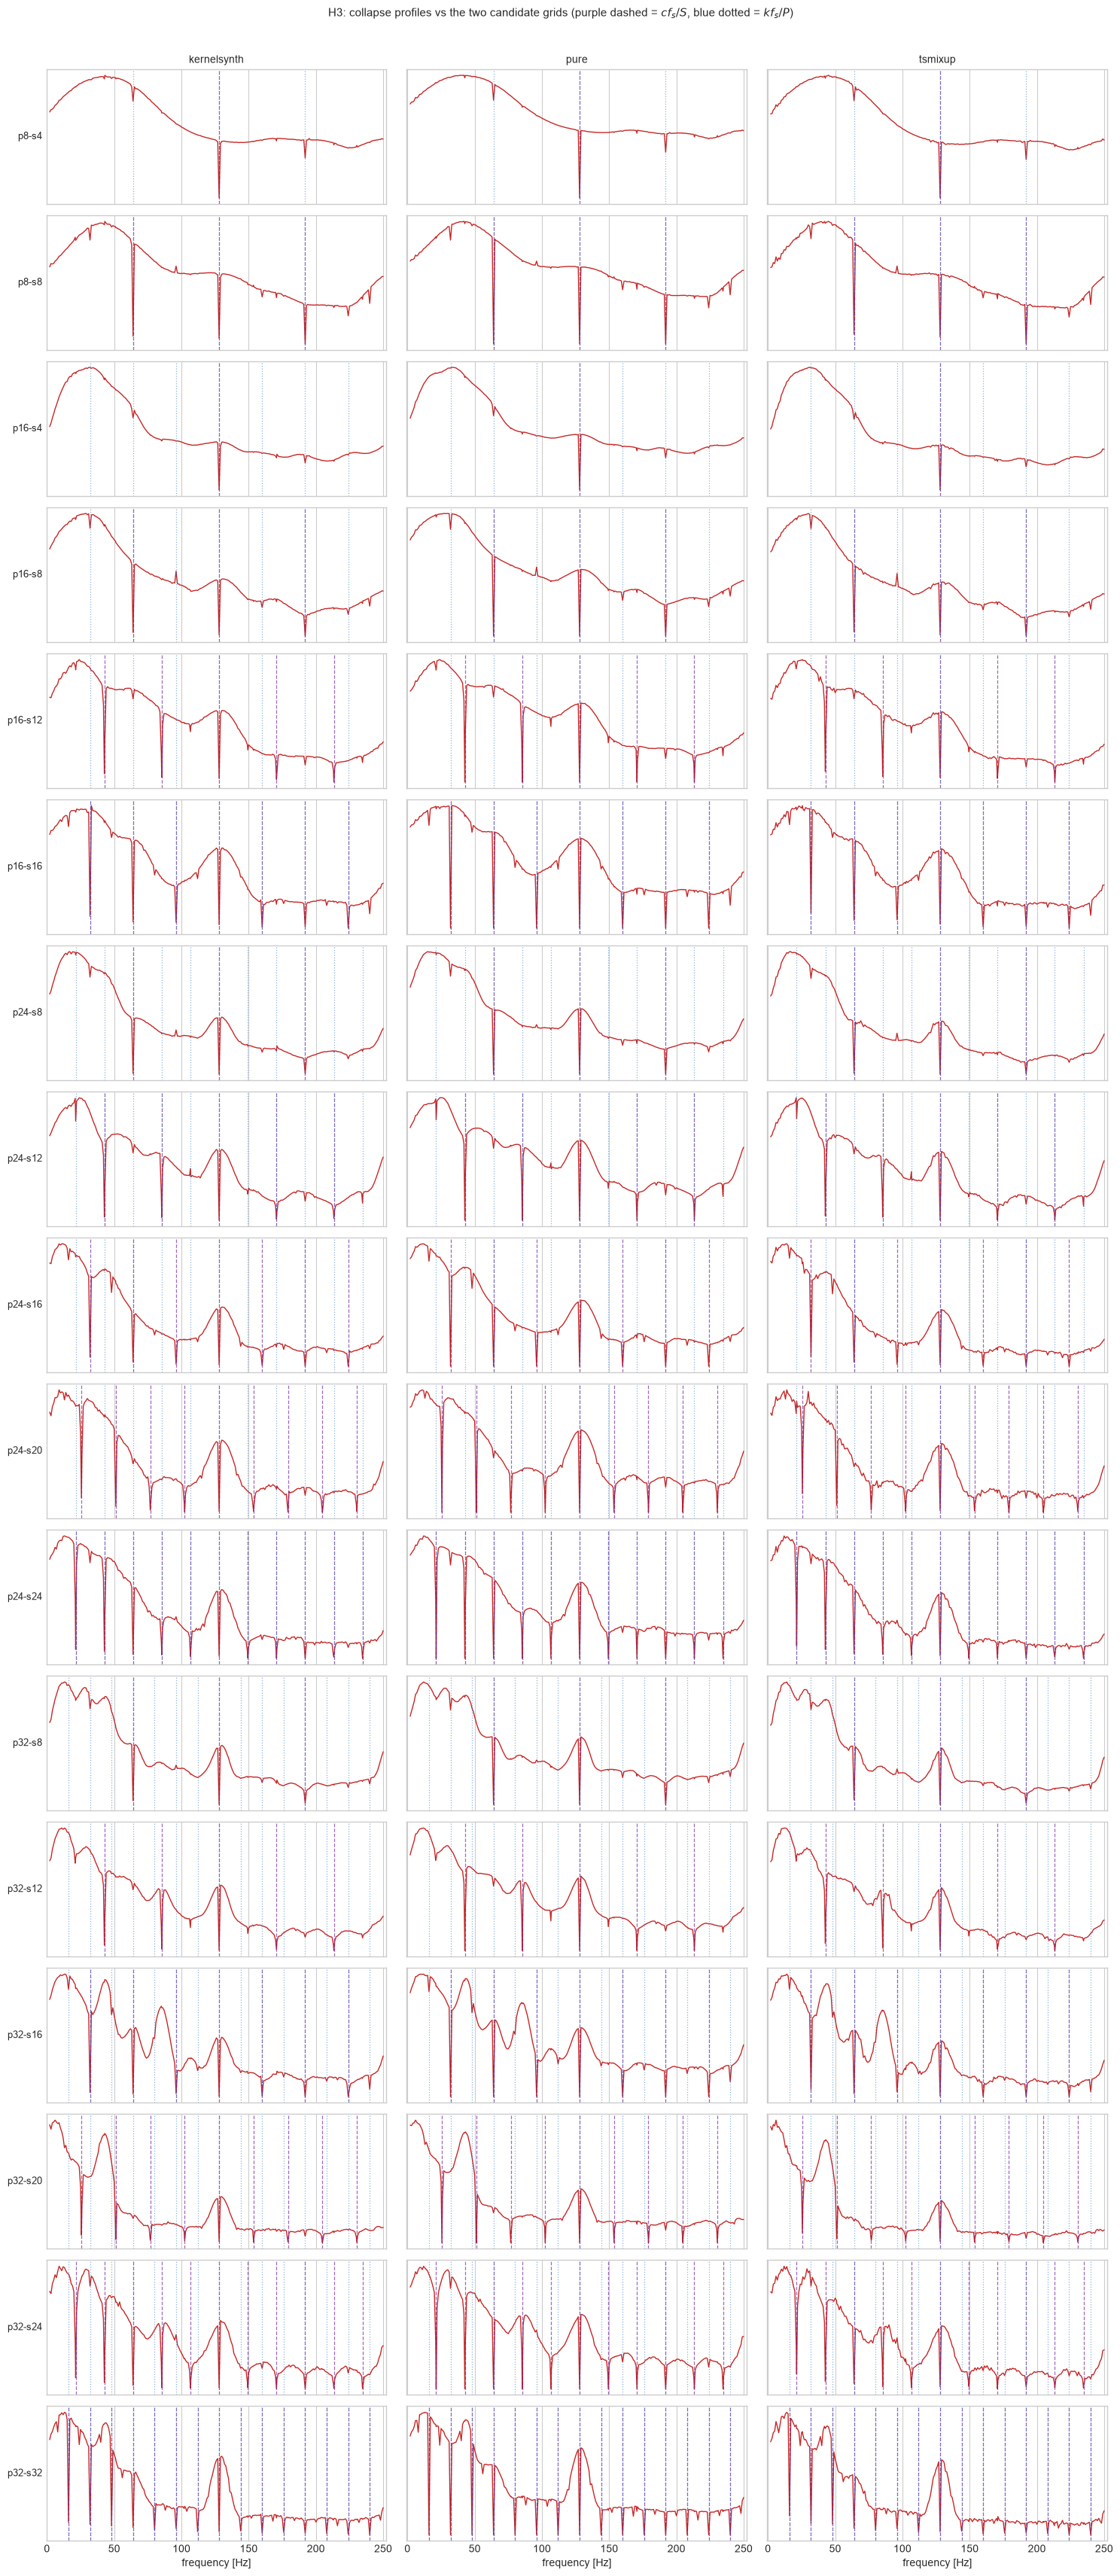

In [26]:
# the observed profiles with both candidate grids drawn on: this is where H3 is visible or not
modes = sorted(collapse["mode"].unique())
geoms = [pl.model_tag(P, S) for P, S in pl.MODELS]
fig, axes = plt.subplots(len(geoms), len(modes), figsize=(5.0 * len(modes), 2.0 * len(geoms)),
                         sharex=True, squeeze=False)
for r, gname in enumerate(geoms):
    for c, mode in enumerate(modes):
        ax = axes[r][c]
        sub = collapse[(collapse["model"] == gname) & (collapse["mode"] == mode)]
        if len(sub) == 0:
            ax.axis("off"); continue
        prof = sub.groupby("f", as_index=False)["z_norm"].mean().sort_values("f")
        P0, S0 = int(sub["P"].iloc[0]), int(sub["S"].iloc[0])
        ax.plot(prof["f"], prof["z_norm"], color="#c62828", lw=1.0)
        for f in pl.stride_locks(S0):
            ax.axvline(f, color="#6a1b9a", ls="--", lw=.9, alpha=.65)
        for f in pl.patch_nulls(P0):
            ax.axvline(f, color="#1565c0", ls=":", lw=.9, alpha=.5)
        ax.set_yticks([]); ax.margins(x=.01)
        if c == 0:
            ax.set_ylabel(gname, rotation=0, ha="right", va="center", fontsize=9)
        if r == 0:
            ax.set_title(mode, fontsize=10)
        if r == len(geoms) - 1:
            ax.set_xlabel("frequency [Hz]")
fig.suptitle("H3: collapse profiles vs the two candidate grids "
             "(purple dashed = $c f_s/S$, blue dotted = $k f_s/P$)", y=1.005, fontsize=11)
fig.tight_layout(); fig.savefig(FIG_DIR / "P4_D1_combs.png", dpi=140, bbox_inches="tight"); plt.show()

## 4.5, Models D2: H3a and H3b, do the sites *move* with the geometry?

$\S 4.4$ says where the dips sit. It does not yet say they *move*: each geometry's grid is fixed,
so a model fitting that grid well is still consistent with dips that merely happen to coincide with
it. H3's actual claim is a law across geometries, and it is **two** laws, one per branch.

$\mathcal F_{lock}$ is a union, so the detected set is the union of two combs and has no single
spacing. Every detected dip is therefore first assigned to the branch that predicts it, sites
belonging to both are set aside, and the fundamental of each branch is compared with the spacing
that branch predicts:

$$\hat f^{\,F}_{1,g} \;\sim\; \mathcal N\!\left(\kappa_F\,\Delta^F_g,\;
\sqrt{\sigma_F^2+\Delta f^2}\right), \qquad
\Delta^S_g = f_s/S_g, \quad \Delta^P_g = f_s/P_g .$$

**H3a predicts $\kappa_S = 1$ and H3b predicts $\kappa_P = 1$**: each branch tracks its own
parameter one for one, so a site that stays put while that parameter changes refutes its branch.

$\kappa_S$ is identified by the series at fixed $P$, which the design supplies at $P=16$ and
$P=24$; $\kappa_P$ by the pairs that share a stride and differ in patch size, at $S=8$, $12$ and
$16$.

The residual carries a floor $\Delta f$, the sweep step: a spacing read off a discrete grid is no
more precise than one step. Without it, sites landing exactly on the prediction drive $\sigma_F$ to
zero and the posterior develops a funnel NUTS cannot traverse. With it, a near-zero $\sigma_F$ is a
result rather than a sampler failure.

Both the fundamental and the median gap are fitted. With three or four sites in band a single
spurious detection inserts a short interval and flips the median, to which the fundamental is
immune, so a disagreement between the two is itself informative about detection stability.


In [27]:
# One row per (geometry, mode, replicate, branch). A branch contributes only if at least two of
# its own sites were detected, since below that there is no spacing to speak of.
sites_fit = sites[(sites["rep"] >= 0) & (sites["n_sites"] >= 2)].copy()
print(f"rows entering D2: {len(sites_fit)}  "
      f"(geometries {sites_fit['model'].nunique()}, modes {sites_fit['mode'].nunique()})")
display(sites_fit.groupby(["branch", "model", "P", "S"])[["f1", "delta_hat", "predicted_spacing"]]
        .agg(["mean", "std"]).round(2))

idata_D2 = {}
for branch in ("stride", "patch"):
    if (sites_fit["branch"] == branch).sum() == 0:
        print(f"  no {branch}-branch rows: that branch is not identified by this collection")
        continue
    idata_D2[branch] = cached_fit(
        f"04_D2_{branch}.nc",
        lambda b=branch: sample(model_D2_movement(sites_fit, b, response="f1"), f"D2_{b}"))

# the fragile estimator, fitted alongside so the two can be compared rather than one chosen
idata_D2d = {b: cached_fit(f"04_D2_{b}_deltahat.nc",
                           lambda b=b: sample(model_D2_movement(sites_fit, b, response="delta_hat"),
                                              f"D2d_{b}"))
             for b in idata_D2}

names = {"stride": "kappa_S", "patch": "kappa_P"}
rowsD2, pD2 = [], {}
for branch, idata in idata_D2.items():
    v = names[branch]
    rowsD2.append(report(idata, v, label=f"{v}  (H3{'a' if branch == 'stride' else 'b'} predicts 1)"))
    pD2[branch] = prob(idata, v, lambda x: np.abs(x - 1.0) < 0.1)      # the ROPE of tab:bayesDecisions
    print(f"\n  P(|{v} - 1| < 0.1 | D) = {pD2[branch]:.3f}   (prior: "
          f"{prior_summary.get('p_kappaS_in_rope_prior', float('nan')):.3f})")
    display(az.summary(idata.posterior, var_names=[v, "sigma_extra"], ci_prob=0.95).round(3))

print("\nkappa_S is identified by the fixed-P series (P=16 and P=24); kappa_P by the pairs that "
      "share a stride and differ in patch size (S=8, 12, 16). A branch with no usable rows is "
      "reported as not identified rather than as a null result.")


rows entering D2: 54  (geometries 6, modes 3)


f1      delta_hat       predicted_spacing     
                       mean  std      mean   std              mean  std
branch model   P  S                                                    
stride p16-s12 16 12  42.67  0.0     42.67  0.00             42.67  0.0
       p24-s16 24 16  32.00  0.0     64.00  0.00             32.00  0.0
       p24-s20 24 20  25.60  0.0     28.44  8.53             25.60  0.0
       p32-s12 32 12  42.67  0.0     42.67  0.00             42.67  0.0
       p32-s20 32 20  25.60  0.0     28.44  8.53             25.60  0.0
       p32-s24 32 24  21.33  0.0     21.33  0.00             21.33  0.0

NUTS[nutpie]: [kappa_S, sigma_extra]


NUTS[nutpie]: [kappa_S, sigma_extra]


  checkpoint -> 04_D2_stride.nc
  no patch-branch rows: that branch is not identified by this collection


  checkpoint -> 04_D2_stride_deltahat.nc
  kappa_S  (H3a predicts 1) median +1.0000   95% CrI [+0.9920, +1.0080]

  P(|kappa_S - 1| < 0.1 | D) = 1.000   (prior: 0.048)


,mean,sd,eti95_lb,eti95_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
kappa_S,1,0.00414,0.99,1,4764,4486,1.00,6e-05,4.2e-05
sigma_extra,0.11,0.086,0.0038,0.32,2605,2058,1.00,0.0014,0.0014



kappa_S is identified by the fixed-P series (P=16 and P=24); kappa_P by the pairs that share a stride and differ in patch size (S=8, 12, 16). A branch with no usable rows is reported as not identified rather than as a null result.


---
# Part 5, Checks

A posterior is a conditional statement: *given* that the sampler converged, that the model can
reproduce the data, and that the answer does not hinge on an arbitrary prior scale. This part tests
all three, and only then states the verdicts.

* **5.1 Convergence**, $\hat R$, bulk and tail ESS, divergences, against the thresholds the
  deliverable preregisters ($\hat R<1.01$, ESS $>1000$, zero divergences).
* **5.2 Posterior predictive**, can the fitted model generate data that look like the observations,
  stratified by frequency, phase, $P$, $S$ and generator? A model that fits the pooled histogram but
  fails a stratum is fitting the average and missing the structure.
* **5.3 Prior sensitivity**, the whole ladder $\{0.25, 0.5, 1.0\}$ plus a Gaussian likelihood. If
  the conclusion moves with the prior scale, it was the prior's conclusion.
* **5.4 Model comparison**, the LOO tables gathered in one place.
* **5.5 Verdicts**, one row per hypothesis, next to the frequentist PASS/FAIL that
  `chronos/testing/hypotheses.py` produces on the same phenomenon.

In [28]:
banner("PART 5, CHECKS")

FITS = {"A (H1 behavioural)": idata_A, "B (H1 representational)": idata_B,
        "C (H2 phase)": idata_C}
# D2 is one fit per branch (H3a stride, H3b patch), so each enters as its own row
for _b, _id in idata_D2.items():
    FITS[f"D2 {_b} branch (H3{'a' if _b == 'stride' else 'b'})"] = _id
for mode, fits in D1.items():
    for label, idata in fits.items():
        FITS[f"D1 {mode} {label.split(':')[0].strip()}"] = idata

diag_rows = []
for name, idata in FITS.items():
    s = az.summary(idata.posterior, ci_prob=0.95)
    div = int(idata.sample_stats["diverging"].values.sum()) if "diverging" in idata.sample_stats else 0
    diag_rows.append(dict(
        fit=name, max_rhat=float(s["r_hat"].max()),
        min_ess_bulk=float(s["ess_bulk"].min()), min_ess_tail=float(s["ess_tail"].min()),
        divergences=div,
        ok=bool(s["r_hat"].max() < 1.01 and s["ess_bulk"].min() > (200 if SMOKE else 1000)
                and s["ess_tail"].min() > (200 if SMOKE else 1000) and div == 0)))
diagnostics = save_df(pd.DataFrame(diag_rows), "05_diagnostics.parquet")
display(diagnostics.round(3))

failed = diagnostics[~diagnostics["ok"]]["fit"].tolist()
print(("all fits meet the preregistered thresholds (R-hat < 1.01, ESS > "
       f"{200 if SMOKE else 1000}, zero divergences)") if not failed
      else f"THRESHOLDS NOT MET for: {failed}, re-run those with more tuning before reporting them.")

PART 5, CHECKS


  checkpoint -> 05_diagnostics.parquet


,fit,max_rhat,min_ess_bulk,min_ess_tail,divergences,ok
0,A (H1 behavioural),1.737,6.149,9.694,0,False
1,B (H1 representational),1.008,572.940,786.996,1,False
2,C (H2 phase),2.110,5.273,9.530,0,False
3,D2 stride branch (H3a),1.002,2605.153,2058.387,0,True
4,D1 kernelsynth M_SP,1.002,9160.240,5517.411,0,True
5,D1 kernelsynth M_S,1.002,13409.882,5281.991,0,True
6,D1 kernelsynth M_P,1.001,12770.743,5943.728,0,True
7,D1 kernelsynth M_0,1.003,17655.777,5483.510,0,True
8,D1 pure M_SP,1.002,10217.102,5489.812,0,True
9,D1 pure M_S,1.002,15035.973,5715.957,0,True


THRESHOLDS NOT MET for: ['A (H1 behavioural)', 'B (H1 representational)', 'C (H2 phase)'], re-run those with more tuning before reporting them.


## 5.2, Posterior predictive checks

Model A is checked pooled and then stratified. The stratified view is the one that matters: a
hierarchical model can reproduce the marginal distribution of $d$ while systematically missing a
configuration or a background generator, and a per-stratum comparison of the observed mean against
the replicated means is what exposes that.

Sampling: [d]


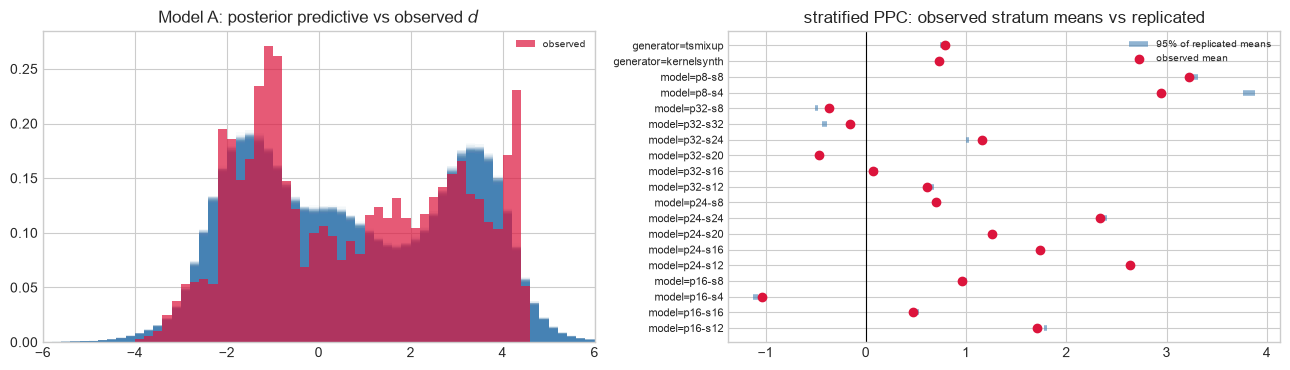

,stratum,n,observed,rep_lo,rep_hi,inside
0,model=p16-s12,8601,1.706,1.773,1.811,False
1,model=p16-s16,4000,0.471,0.482,0.535,False
2,model=p16-s4,6744,-1.032,-1.121,-1.075,False
3,model=p16-s8,4000,0.956,0.942,1.005,True
4,model=p24-s12,7733,2.640,2.636,2.674,True
5,model=p24-s16,8000,1.742,1.734,1.770,True
6,model=p24-s20,8600,1.260,1.231,1.272,True
7,model=p24-s24,7689,2.331,2.365,2.405,False
8,model=p24-s8,11342,0.704,0.671,0.703,False
9,model=p32-s12,14495,0.608,0.652,0.680,False


strata covered by the replicated interval: 6/19


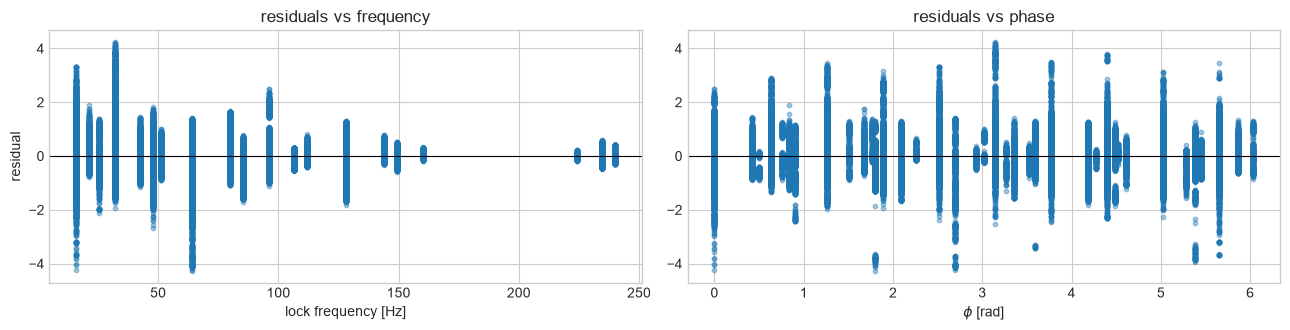

In [29]:
with model_A_contrast(live):
    ppc_A = pm.sample_posterior_predictive(idata_A, random_seed=SEED, progressbar=False)
for _k in ppc_A.children: idata_A[_k] = ppc_A[_k]

fig, ax = plt.subplots(1, 2, figsize=(13, 3.8))
# az.plot_ppc removed in ArviZ 1.x; manual PPC plot
obs_d = idata_A.observed_data["d"].values
pp_d = ppc_A.posterior_predictive["d"].values.reshape(-1, len(obs_d))
for k in range(min(80, pp_d.shape[0])):
    ax[0].hist(pp_d[k], bins=60, range=(-6, 6), density=True, alpha=0.03, color="steelblue")
ax[0].hist(obs_d, bins=60, range=(-6, 6), density=True, alpha=0.7, color="crimson", label="observed")
ax[0].legend(fontsize=7)
ax[0].set_title("Model A: posterior predictive vs observed $d$"); ax[0].set_xlim(-6, 6)

rep = ppc_A.posterior_predictive["d"].values.reshape(-1, len(live))
strata = []
for col in ["model", "generator"]:
    for lvl, idx in live.groupby(col).groups.items():
        pos = live.index.get_indexer(idx)
        obs_m = live["d"].to_numpy()[pos].mean()
        rep_m = rep[:, pos].mean(axis=1)
        strata.append(dict(stratum=f"{col}={lvl}", n=len(pos), observed=obs_m,
                           rep_lo=np.quantile(rep_m, .025), rep_hi=np.quantile(rep_m, .975),
                           inside=bool(np.quantile(rep_m, .025) <= obs_m <= np.quantile(rep_m, .975))))
strat = pd.DataFrame(strata)

yv = np.arange(len(strat))
ax[1].hlines(yv, strat["rep_lo"], strat["rep_hi"], color="steelblue", lw=4, alpha=.6,
             label="95% of replicated means")
ax[1].scatter(strat["observed"], yv, color="crimson", zorder=3, label="observed mean")
ax[1].set_yticks(yv); ax[1].set_yticklabels(strat["stratum"], fontsize=8)
ax[1].axvline(0, color="k", lw=.8); ax[1].legend(fontsize=7)
ax[1].set_title("stratified PPC: observed stratum means vs replicated")
fig.tight_layout(); fig.savefig(FIG_DIR / "P5_ppc.png", dpi=140, bbox_inches="tight"); plt.show()

display(strat.round(3))
print(f"strata covered by the replicated interval: {int(strat['inside'].sum())}/{len(strat)}")

# frequency- and phase-resolved residuals: the two axes H1 and H2 live on
live_r = live.copy(); live_r["resid"] = live["d"].to_numpy() - rep.mean(axis=0)
fig, ax = plt.subplots(1, 2, figsize=(13, 3.4))
ax[0].scatter(live_r["f_lock"], live_r["resid"], s=10, alpha=.4); ax[0].axhline(0, color="k", lw=.8)
ax[0].set_xlabel("lock frequency [Hz]"); ax[0].set_ylabel("residual"); ax[0].set_title("residuals vs frequency")
ax[1].scatter(np.mod(live_r["phase"], 2 * np.pi), live_r["resid"], s=10, alpha=.4)
ax[1].axhline(0, color="k", lw=.8); ax[1].set_xlabel(r"$\phi$ [rad]"); ax[1].set_title("residuals vs phase")
fig.tight_layout(); fig.savefig(FIG_DIR / "P5_residuals.png", dpi=140, bbox_inches="tight"); plt.show()

## 5.3, Prior sensitivity

Model A is refitted across the preregistered scale ladder and with a Gaussian likelihood in place
of the Student-$t_4$. The conclusion is only reportable if $\Pr(\bar\beta<\log 0.8\mid D)$ and the
credible interval are stable across all four, otherwise the analysis is reporting the prior, or the
robustness of the likelihood, rather than the data.

NUTS[nutpie]: [beta_bar, delta_O, delta_P, tau, z_cfg, sigma_harm, z_harm, sigma_bg, z_bg, sigma]


NUTS[nutpie]: [beta_bar, delta_O, delta_P, tau, z_cfg, sigma_harm, z_harm, sigma_bg, z_bg, sigma]


NUTS[nutpie]: [beta_bar, delta_O, delta_P, tau, z_cfg, sigma_harm, z_harm, sigma_bg, z_bg, sigma]


NUTS[nutpie]: [beta_bar, delta_O, delta_P, tau, z_cfg, sigma_harm, z_harm, sigma_bg, z_bg, sigma]


  checkpoint -> 05_sensitivity.parquet


,variant,median,lo,hi,ratio,P_attenuation_20,P_in_rope
0,StudentT scale 0.25,-0.0730,-0.4028,0.4728,0.9296,0.2145,0.2095
1,StudentT scale 0.5,-0.2027,-0.6997,0.0808,0.8165,0.4645,0.3175
2,StudentT scale 1.0,-0.0036,-0.8565,0.3253,0.9964,0.3225,0.2900
3,"Normal likelihood, scale 0.5",-0.0075,-0.6325,0.4311,0.9926,0.2470,0.2280



spread of P(>=20% attenuation) across prior scales and likelihoods: 0.250
  >= 0.10 -> the conclusion depends on the prior scale; report the whole ladder, not one number.


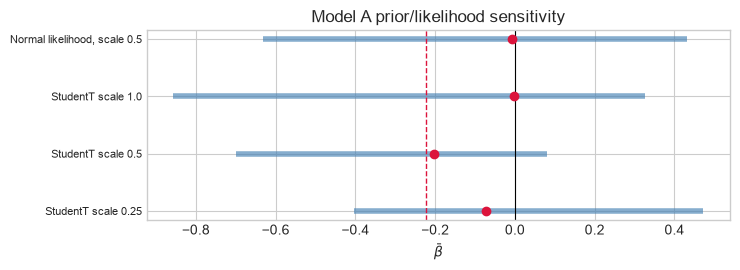

In [30]:
if have("05_sensitivity.parquet"):
    sens = load_df("05_sensitivity.parquet")
else:
    rows = []
    variants = [(f"StudentT scale {s}", dict(scale=s, likelihood="student")) for s in PRIOR_LADDER]
    variants += [("Normal likelihood, scale 0.5", dict(scale=0.5, likelihood="normal"))]
    for label, kw in variants:
        idata = sample(model_A_contrast(live, **kw), label,
                       draws=max(400, DRAWS // 2), tune=max(400, TUNE // 2), chains=2)
        post = idata.posterior["beta_bar"].values.ravel()
        rows.append(dict(variant=label, median=float(np.median(post)),
                         lo=float(np.quantile(post, .025)), hi=float(np.quantile(post, .975)),
                         ratio=float(np.exp(np.median(post))),
                         P_attenuation_20=float(np.mean(post < ATTENUATION_20)),
                         P_in_rope=float(np.mean(np.abs(post) < ROPE_LOG))))
    sens = save_df(pd.DataFrame(rows), "05_sensitivity.parquet")

display(sens.round(4))
spread = sens["P_attenuation_20"].max() - sens["P_attenuation_20"].min()
print(f"\nspread of P(>=20% attenuation) across prior scales and likelihoods: {spread:.3f}")
print("  < 0.10 -> the conclusion is a property of the data, not of the prior."
      if spread < 0.10 else
      "  >= 0.10 -> the conclusion depends on the prior scale; report the whole ladder, not one number.")

fig, ax = plt.subplots(figsize=(7.5, 2.8))
yv = np.arange(len(sens))
ax.hlines(yv, sens["lo"], sens["hi"], lw=4, color="steelblue", alpha=.65)
ax.scatter(sens["median"], yv, color="crimson", zorder=3)
ax.axvline(0, color="k", lw=.8); ax.axvline(ATTENUATION_20, color="crimson", ls="--", lw=1)
ax.set_yticks(yv); ax.set_yticklabels(sens["variant"], fontsize=8)
ax.set_xlabel(r"$\bar\beta$"); ax.set_title("Model A prior/likelihood sensitivity")
fig.tight_layout(); fig.savefig(FIG_DIR / "P5_sensitivity.png", dpi=140, bbox_inches="tight"); plt.show()

## 5.4, Model comparisons in one place

Where the deliverable pits formulations against each other, leave-one-out cross-validation decides.
`elpd_diff` is the difference in expected log pointwise predictive density and `dse` its standard
error: a difference smaller than about two standard errors is not a decision, and is reported as
such rather than rounded up into one.

In [31]:
print("H2, phase-dependent vs phase-free (Model C)"); display(cmpC)
print("\nH3, competing combs, per signal mode (Model D1)")
display(cmpD1[["mode", "model", "rank", "elpd", "elpd_diff", "dse", "weight"]].round(2))
print("\nModel B, blocking on probe stage vs Eq. (10) literal"); display(cmpB)

def loo_verdict(cmp_df, winner_row=0) -> str:
    """Turn an ArviZ comparison into a sentence that respects its own standard error."""
    d = cmp_df.sort_values("rank")
    if len(d) < 2:
        return "single model"
    second = d.iloc[1]
    diff, dse = abs(float(second["elpd_diff"])), float(second["dse"])
    if dse == 0 or diff < 2 * dse:
        return f"inconclusive (elpd_diff {diff:.1f} < 2*dse {2 * dse:.1f})"
    return f"{d.index[0]} preferred (elpd_diff {diff:.1f} vs dse {dse:.1f})"

print("\nreadings:")
print("  H2 :", loo_verdict(cmpC))
for mode in sorted(D1):
    sub = cmpD1[cmpD1["mode"] == mode].set_index("model")
    print(f"  H3 ({mode}):", loo_verdict(sub))

H2, phase-dependent vs phase-free (Model C)


,rank,elpd_diff,dse,p_worse,diag_diff,diag_elpd,p,elpd,se,weight
phase-dependent (H2 refuted),0,0.0,0.0,NaN,,,71.9,-137500.0,390.0,1.0
phase-free (H2 holds),1,-150.0,17.0,1.0,,,70.1,-137600.0,390.0,0.0



H3, competing combs, per signal mode (Model D1)


,mode,model,rank,elpd,elpd_diff,dse,weight
0,kernelsynth,M_S : sites on c*fs/S,0,-5600.0,0.0,0.0,0.44
1,kernelsynth,M_SP: both grids (H3),1,-5600.0,-1.0,1.1,0.44
2,kernelsynth,M_P : sites on k*fs/P,2,-5900.0,-320.0,30.0,0.00
3,kernelsynth,M_0 : no grid effect,3,-6000.0,-410.0,35.0,0.12
4,pure,M_S : sites on c*fs/S,0,-15200.0,0.0,0.0,0.05
5,pure,M_SP: both grids (H3),1,-15200.0,-1.0,1.6,0.77
6,pure,M_P : sites on k*fs/P,2,-16900.0,-1600.0,110.0,0.00
7,pure,M_0 : no grid effect,3,-17200.0,-2000.0,130.0,0.18
8,tsmixup,M_S : sites on c*fs/S,0,-4000.0,0.0,0.0,0.48
9,tsmixup,M_SP: both grids (H3),1,-4000.0,-0.0,1.2,0.44



Model B, blocking on probe stage vs Eq. (10) literal


,rank,elpd_diff,dse,p_worse,diag_diff,diag_elpd,p,elpd,se,weight
stage+geometry adjusted,0,0.0,0.0,NaN,,,26.3,-29300.0,54.0,0.99
Eq. (10) literal,1,-470.0,29.0,1.0,,,2.4,-29790.0,48.0,0.01



readings:
  H2 : phase-dependent (H2 refuted) preferred (elpd_diff 150.0 vs dse 17.0)
  H3 (kernelsynth): inconclusive (elpd_diff 1.0 < 2*dse 2.2)
  H3 (pure): inconclusive (elpd_diff 1.0 < 2*dse 3.2)
  H3 (tsmixup): inconclusive (elpd_diff 0.0 < 2*dse 2.4)


## 5.5, Verdicts

Each hypothesis is decided by the rule fixed in Part 1, before the data existed. The frequentist
column is the PASS/FAIL that `chronos/testing/hypotheses.py` reports on the same phenomenon; where
the two disagree, the Bayesian row says *how strongly*, which is the point of doing this at all.

In [32]:
def verdict(p: float, hi: float = 0.95, lo: float = 0.05) -> str:
    """Three-way reading: supported, refuted, or genuinely undecided by these data."""
    return "SUPPORTED" if p >= hi else ("REFUTED" if p <= lo else "INCONCLUSIVE")

h3_mode = "tsmixup" if "tsmixup" in D1 else sorted(D1)[0]
h3_cmp = cmpD1[cmpD1["mode"] == h3_mode].sort_values("rank")
h3_best = str(h3_cmp.iloc[0]["model"])

verdicts = pd.DataFrame([
    dict(hypothesis="H1 (behavioural)", model="A", estimand="exp(beta_bar): recovery at lock / control",
         posterior=f"{np.exp(np.median(idata_A.posterior['beta_bar'].values)):.3f} "
                   f"[{np.exp(np.quantile(idata_A.posterior['beta_bar'].values, .025)):.3f}, "
                   f"{np.exp(np.quantile(idata_A.posterior['beta_bar'].values, .975)):.3f}]",
         decision_rule="P(beta_bar < log 0.8) >= 0.95", probability=round(pA_att, 3),
         verdict=verdict(pA_att)),
    dict(hypothesis="H1 (representational)", model="B", estimand="exp(theta_lock): codelength at lock / control",
         posterior=f"{np.exp(np.median(idata_B.posterior['theta_lock'].values)):.3f} "
                   f"[{np.exp(np.quantile(idata_B.posterior['theta_lock'].values, .025)):.3f}, "
                   f"{np.exp(np.quantile(idata_B.posterior['theta_lock'].values, .975)):.3f}]",
         decision_rule="P(theta_lock > log 1.2) >= 0.95", probability=round(pB_20, 3),
         verdict=verdict(pB_20)),
    dict(hypothesis="H2 (phase invariance)", model="C", estimand="sigma_phase: spread across phase",
         posterior=f"{np.median(idata_C.posterior['sigma_phase'].values):.3f} "
                   f"[{np.quantile(idata_C.posterior['sigma_phase'].values, .025):.3f}, "
                   f"{np.quantile(idata_C.posterior['sigma_phase'].values, .975):.3f}]",
         decision_rule="P(sigma_phase < log 1.1) >= 0.95", probability=round(pC_rope, 3),
         verdict=verdict(pC_rope)),
    dict(hypothesis="H3 (site location)", model="D1",
         estimand=f"LOO winner among M_SP / M_S / M_P / M_0 [{h3_mode}]",
         posterior=h3_best, decision_rule="two-label fit wins, theta_S and theta_P < 0",
         probability=np.nan,
         verdict=("SUPPORTED" if h3_best.startswith("M_SP")
                  and "inconclusive" not in loo_verdict(h3_cmp.set_index("model"))
                  else "SEE LOO TABLE")),
    dict(hypothesis="M1 (mitigation by overlap)", model="A'",
         estimand="delta_O: change in the deficit per unit of overlap",
         posterior=f"{np.median(idata_A.posterior['delta_O'].values):.3f} "
                   f"[{np.quantile(idata_A.posterior['delta_O'].values, .025):.3f}, "
                   f"{np.quantile(idata_A.posterior['delta_O'].values, .975):.3f}]",
         decision_rule="P(delta_O < 0) >= 0.95 and the overlap term wins LOO",
         probability=round(pA_mit, 3), verdict=verdict(pA_mit)),
])

# H3a and H3b: one row per branch, and a branch with no usable rows is reported as NOT
# IDENTIFIED rather than as a null result (tab:bayesModels lists both as separate claims).
for _br, _hyp, _kap in (("stride", "H3a", "kappa_S"), ("patch", "H3b", "kappa_P")):
    if _br in idata_D2:
        _k = idata_D2[_br].posterior[_kap].values.ravel()
        _row = dict(posterior=f"{np.median(_k):.3f} [{np.quantile(_k, .025):.3f}, "
                              f"{np.quantile(_k, .975):.3f}]",
                    probability=round(pD2[_br], 3), verdict=verdict(pD2[_br]))
    else:
        _row = dict(posterior="not identified by this collection", probability=np.nan,
                    verdict="NOT IDENTIFIED")
    verdicts.loc[len(verdicts)] = dict(
        hypothesis=f"{_hyp} ({_br} branch)", model="D2",
        estimand=f"{_kap}: measured / {_br}-predicted spacing",
        decision_rule=f"P(|{_kap} - 1| < {ROPE_SLOPE}) >= 0.95", **_row)

_freq = {"H1 (behavioural)": "REFUTED in its strong form", "H1 (representational)": "not tested",
         "H2 (phase invariance)": "SUPPORTED (CV 0.01-0.16)", "H3 (site location)": "SUPPORTED",
         "M1 (mitigation by overlap)": "not tested", "H3a (stride branch)": "SUPPORTED",
         "H3b (patch branch)": "not tested"}
verdicts["frequentist (hypotheses.py)"] = verdicts["hypothesis"].map(_freq).fillna("not tested")
save_df(verdicts, "05_verdicts.parquet")
pd.set_option("display.max_colwidth", 52)
display(verdicts)

print(f"\ncheckpoints : {CKPT_DIR}")
print(f"figures     : {FIG_DIR}")
print(f"tables      : {DATA_DIR}")
if SMOKE:
    print("\n*** SMOKE RUN, these numbers are from a deliberately tiny design and must not be "
          "reported. Set SMOKE = False in Part 0.3 and re-run. ***")

  checkpoint -> 05_verdicts.parquet


,hypothesis,model,estimand,posterior,decision_rule,probability,verdict,frequentist (hypotheses.py)
0,H1 (behavioural),A,exp(beta_bar): recovery at lock / control,"1.027 [0.674, 1.908]",P(beta_bar < log 0.8) >= 0.95,0.137,INCONCLUSIVE,REFUTED in its strong form
1,H1 (representational),B,exp(theta_lock): codelength at lock / control,"1.268 [1.235, 1.303]",P(theta_lock > log 1.2) >= 0.95,1.000,SUPPORTED,not tested
2,H2 (phase invariance),C,sigma_phase: spread across phase,"0.033 [0.020, 0.068]",P(sigma_phase < log 1.1) >= 0.95,0.997,SUPPORTED,SUPPORTED (CV 0.01-0.16)
3,H3 (site location),D1,LOO winner among M_SP / M_S / M_P / M_0 [tsmixup],M_S : sites on c*fs/S,"two-label fit wins, theta_S and theta_P < 0",NaN,SEE LOO TABLE,SUPPORTED
4,M1 (mitigation by overlap),A',delta_O: change in the deficit per unit of overlap,"0.453 [0.011, 0.821]",P(delta_O < 0) >= 0.95 and the overlap term wins...,0.023,REFUTED,not tested
5,H3a (stride branch),D2,kappa_S: measured / stride-predicted spacing,"1.000 [0.992, 1.008]",P(|kappa_S - 1| < 0.1) >= 0.95,1.000,SUPPORTED,SUPPORTED
6,H3b (patch branch),D2,kappa_P: measured / patch-predicted spacing,not identified by this collection,P(|kappa_P - 1| < 0.1) >= 0.95,NaN,NOT IDENTIFIED,not tested



checkpoints : C:\Users\feder\Desktop\patchAliasing\chronos\bayesian\_run\full
figures     : C:\Users\feder\Desktop\patchAliasing\chronos\bayesian\_run\full\figures
tables      : C:\Users\feder\Desktop\patchAliasing\chronos\bayesian\_run\full\data


---
## How to read a disagreement with the frequentist suite

`hypotheses.py` answers "did the average contrast come out negative on most live locks?"; Model A
answers "given the design's hierarchy, how large is the population effect and how sure are we?".
They can differ for good reasons, and the differences are the interesting part:

* a PASS with a wide credible interval spanning zero means the point estimate happened to land on
  the right side of a threshold, not that the effect is established;
* a FAIL with a posterior concentrated slightly below the ROPE means a real but small effect that a
  binary rule discards;
* `INCONCLUSIVE` is a genuine third outcome. It says these data do not decide, which for the
  under-trained variants, half the published training budget, one seed, is frequently the honest
  answer, and it is not available to a PASS/FAIL test at all.

The single-seed caveat applies throughout: with one checkpoint per geometry, every statement is
conditional on that checkpoint, and the configuration-level spread $\tau$ absorbs training noise
that a multi-seed design would separate out.